# External Swarm tables in a COMSOL 1D argon DC glow discharge

## tl;dr

- Evidence status: **provisional_2026-07-14**; data-quality decision: **share_with_caveats**.
- Profile comparison/runtime evidence: **provisional_profile_comparison_2026-07-14**; lookup curves: **schema_v2_tail_grid_pass_solver_gate_incomplete_2026-07-31**.
- The application-library basis is the full electrode-gap **1D DC glow discharge** (cathode fall, dark-space/column structure, and anode side), not an isolated uniform positive-column calculation.
- The external path is a **selected-channel hybrid**: Swarm supplies four transport quantities and direct eir2/eir4 Townsend data, while COMSOL retains the LEA fluid equations and residual chemistry/energy treatment.
- The bundle carries **7 lookup quantities = 7 X-Y pairs = 14 numerical arrays**. In archived LEA, the E/N-to-mean-energy pair is stored but inactive; written properties and equation-level activation are distinct.
- Tail/grid criteria pass **34/34** points, but the iterative solver convergence flag passes only **23/34**; therefore the full Swarm case gate passes **23/34**.
- Runtime repetition gate: **False**; raw 200/400 mesh gate: **False**.
- Exact piecewise-linear L2 and spatial integral ratio are reported separately; the built-in result is a reference, not ground truth.

## Context & Methods

This companion notebook regenerates **19 derived CSVs and 9 static figures** without modifying raw COMSOL or Swarm outputs. The archived COMSOL profiles are final-time BDF profiles; a stationarity residual was not exported, so they are not promoted to independently verified steady states.

### Key Assumptions

- Profiles overlap over a common 1D interval and are linearly interpolated onto the union of their x coordinates.
- Integrals of the reconstructed profiles, their squares, and their products are evaluated exactly on every piecewise-linear interval. Trapezoidal integration of squared nodal samples is retained only as a sensitivity diagnostic.
- E/N in exported profiles is V m² and is converted using 1 Td = 10⁻²¹ V m².
- Central 80% means 10% of physical domain length removed at each end; it is a geometric window, not a physical bulk/sheath definition.
- `excitation_source` and `ionization_source` are eir2 direct excitation and eir4 direct ionization, not net reaction sources. `total_current_density` is electron + Ar⁺ conductive current.
- E/N > 500 Td is COMSOL's typical drift-diffusion regime guidance, not a hard validity cutoff.
- The Townsend source representation is \(S_T=(\alpha/N)N|J_e|/e\). The notebook's \(Nn_e k\) reconstruction is a counterfactual postprocess, not a matched COMSOL rerun and not evidence that one representation is better.
- Timing rows are independent only when the run process that produced them was independently launched; the notebook cannot infer this from numbers alone.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
CONFIG = PROJECT_ROOT / 'reports/comsol_swarm_benchmark_2026/repro/analysis_inputs.json'
REPORT_ROOT = PROJECT_ROOT / 'reports/comsol_swarm_benchmark_2026'
DATA_DIR = PROJECT_ROOT / 'reports/comsol_swarm_benchmark_2026/data/derived'
assert CONFIG.exists() and DATA_DIR.exists()
print(f'Config: {CONFIG.relative_to(PROJECT_ROOT)}')

Config: reports\comsol_swarm_benchmark_2026\repro\analysis_inputs.json


## Data

### 1. Regenerate analysis products

The checked-in analysis module is the single implementation of metric definitions used by this notebook and the report.

In [2]:
import importlib.util
import sys

module_path = REPORT_ROOT / 'repro/benchmark_analysis.py'
spec = importlib.util.spec_from_file_location('benchmark_analysis_runtime', module_path)
analysis = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = analysis
spec.loader.exec_module(analysis)
summary = analysis.run_analysis(CONFIG)
{key: summary[key] for key in ['evidence_status', 'data_vintages', 'formal_gates']}

{'evidence_status': 'provisional_2026-07-14',
 'data_vintages': {'profile_comparison': 'provisional_profile_comparison_2026-07-14',
  'runtime_and_mesh': 'provisional_profile_comparison_2026-07-14',
  'lookup_tables': 'schema_v2_tail_grid_pass_solver_gate_incomplete_2026-07-31',
  'lookup_range_overlay': 'lookup curves: schema_v2_tail_grid_pass_solver_gate_incomplete_2026-07-31; COMSOL-used field range: provisional_profile_comparison_2026-07-14',
  'historical_activation_audit': 'intended historical bundle versus archived export; stale-class provenance unresolved'},
 'formal_gates': {'runtime_repetition_gate_met': False,
  'formal_swarm_tail_convergence_gate_met': True,
  'formal_swarm_solver_convergence_gate_met': False,
  'formal_swarm_all_case_gates_met': False,
  'raw_mesh_200_400_gate_met': False,
  'profile_voltage_pressure_match': True,
  'historical_closure_gas_conditions_match': False,
  'formal_target_conditions_configured_to_match': True,
  'formal_run_conditions_verified': 

### 2. Verify the 19-table contract, source hashes, and data-quality checks

In [3]:
DERIVED_CSV_CONTRACT = [
    'aligned_profiles_long.csv', 'clamp_impact.csv', 'clamp_metrics.csv',
    'comparison_metrics.csv', 'current_rsd_sensitivity.csv',
    'current_uniformity.csv', 'fluid_applicability_diagnostics.csv',
    'historical_activation_audit.csv', 'operating_point_diagnostics.csv',
    'partial_electron_energy_audit.csv', 'qa_summary.csv',
    'regime_impact.csv', 'regime_metrics.csv',
    'regional_error_attribution.csv', 'runtime_speedup.csv',
    'runtime_summary.csv', 'source_hashes.csv',
    'tail_convergence_audit.csv',
    'townsend_source_representation_audit.csv',
]
actual_csvs = sorted(path.name for path in DATA_DIR.glob('*.csv'))
assert actual_csvs == sorted(DERIVED_CSV_CONTRACT), (actual_csvs, DERIVED_CSV_CONTRACT)
print(f'Derived CSV contract: {len(actual_csvs)}/19 files present')

source_hashes = pd.read_csv(DATA_DIR / 'source_hashes.csv')
qa = pd.read_csv(DATA_DIR / 'qa_summary.csv')
display(source_hashes)
display(qa.loc[~qa['passed'], ['source_id', 'check', 'observed', 'expected', 'severity_if_failed']])

Derived CSV contract: 19/19 files present


,source_id,path,bytes,sha256
0,config,reports/comsol_swarm_benchmark_2026/repro/anal...,4258,a6ba8bd2843f86bcfc5cf1f1c873084d05c7567d20abc6...
1,analysis_code,reports/comsol_swarm_benchmark_2026/repro/benc...,173679,9d614f1ea30298bd6a790f3d8695eb688abbf663ca1d2d...
2,external_profile,reports/comsol_swarm_benchmark_2026/data/archi...,223036,b632cd3edf7e1a9383608332dae39cb5adfc637b49c9a3...
3,reference_profile,reports/comsol_swarm_benchmark_2026/data/archi...,174857,1f3eb1461ec08f70a590d60a8802d207126fbc0ca8c003...
4,runtime,reports/comsol_swarm_benchmark_2026/data/provi...,584,d0386c1c47bf21e7c9a3bed9d483873e6c7ae0e2d1466f...
5,bundle_manifest,reports/comsol_swarm_benchmark_2026/data/forma...,9604,cc5be10636e1c1885f97a55088793b31754e1ad4832d35...
6,bundle_transport,reports/comsol_swarm_benchmark_2026/data/forma...,6461,e7315c9c29d23abcdc8bf054ea1afba8a34325b44bc6cd...
7,bundle_rates,reports/comsol_swarm_benchmark_2026/data/forma...,16359,8008fdc9f70dc948a8c7f904a55020d900eec49cfdfae7...
8,bundle_mean_energy,reports/comsol_swarm_benchmark_2026/data/forma...,1746,f541ee619ae71ad9d9c43047a860e58cc171a0bb851fa1...
9,formal_swarm_database,reports/comsol_swarm_benchmark_2026/data/forma...,4505600,637490605208355b114752c4116ad4b5d3a66ee78f6a9b...


,source_id,check,observed,expected,severity_if_failed
20,condition_audit,historical_closure_gas_conditions_match,"Swarm={'gas_temperature_K': 300.0, 'pressure_P...",identical gas_temperature_K and pressure_Pa,high
21,historical_activation_audit,historical_activation_provenance_verified,verified=False; numeric_mismatch_rows=1; archi...,clean class bound by hash to intended bundle a...,high
26,condition_audit,formal_run_conditions_verified,False,True,high
27,runtime,solve_only_external_swarm_repetitions,1,>=3,high
28,runtime,solve_only_builtin_reference_repetitions,1,>=3,high
29,runtime,end_to_end_external_swarm_repetitions,1,>=3,high
30,runtime,end_to_end_builtin_reference_repetitions,1,>=3,high
31,mesh_profiles,raw_mesh_profiles_available,raw=[200]; summary_fallback=True,"raw profiles for [200, 400]",high
33,formal_swarm_database,formal_swarm_tail_convergence,cases=34; tail/grid failures=0; solver-converg...,"every case converged, tail<=target, edge/peak<...",critical


## Results

### 3. Exact piecewise-linear spatial metrics

Relative L2 integrates the square of the continuous piecewise-linear reconstruction exactly. The adjacent signed integral ratio tests net magnitude, and the correlation tests co-variation after exact spatial centering. The trapezoidal-of-squared-samples column quantifies numerical sensitivity, especially for edge-local current spikes.

In [4]:
metrics = pd.read_csv(DATA_DIR / 'comparison_metrics.csv')
display(metrics[['quantity_label', 'relative_L2_spatial_weighted', 'relative_L2_trapezoidal_of_squared_samples_sensitivity', 'integral_ratio_external_over_reference', 'shape_correlation_spatial_weighted', 'legacy_L2_unweighted_discrete']].round(6))

,quantity_label,relative_L2_spatial_weighted,relative_L2_trapezoidal_of_squared_samples_sensitivity,integral_ratio_external_over_reference,shape_correlation_spatial_weighted,legacy_L2_unweighted_discrete
0,Electron density,0.529803,0.529804,0.484417,0.995008,0.517766
1,Mean electron energy,0.661821,0.661921,1.457392,0.778464,0.566597
2,Electric potential,0.153301,0.153301,1.152015,0.993787,0.142807
3,E/N,0.155723,0.155752,1.188228,0.992885,0.113266
4,Electron current density,0.366197,0.426286,0.866875,0.592499,0.728826
5,Electron + Ar$^+$ conductive current,0.351166,0.407926,0.854467,-0.116103,0.670711
6,Direct excitation source (eir2),0.808395,0.810713,0.938939,0.645930,0.554796
7,Direct ionization source (eir4),0.802045,0.803551,0.718303,0.785001,0.639510


### 4. Lookup coverage and Swarm tail/solver gates

The LEA equations query active transport and Townsend data by mean electron energy. Therefore the mean-energy boundary-policy rows are primary; the low-E/N row is secondary because the E/N-to-mean-energy pair is inactive in the archived LEA formulation. Tail/grid adequacy and iterative solver convergence are audited independently.

In [5]:
clamp = pd.read_csv(DATA_DIR / 'clamp_metrics.csv')
clamp_impact = pd.read_csv(DATA_DIR / 'clamp_impact.csv')
tail = pd.read_csv(DATA_DIR / 'tail_convergence_audit.csv')
tail_summary = pd.Series({
    'formal points': len(tail),
    'tail/grid gate pass': int(tail['formal_tail_grid_gate_pass'].sum()),
    'solver convergence gate pass': int(tail['formal_solver_convergence_gate_pass'].sum()),
    'all-case gate pass': int(tail['formal_swarm_case_gate_pass'].sum()),
}, name='count')
display(clamp)
display(clamp_impact[['region', 'quantity_label', 'absolute_integral_share']].round(6))
display(tail_summary.to_frame())
display(tail.loc[~tail['formal_swarm_case_gate_pass'], [
    'E_over_N_Td', 'solver_converged', 'iterations', 'residual_L1',
    'grid_max_eV', 'tail_probability', 'edge_to_peak',
    'formal_tail_grid_gate_pass',
    'formal_solver_convergence_gate_pass',
]])

,evidence_status,metric,predicate,threshold,threshold_unit,spatial_length_m,spatial_fraction,node_fraction
0,provisional_2026-07-14,E_over_N_below_table,below,0.044400,Td,0.000257,0.000698,0.001248
1,provisional_2026-07-14,E_over_N_above_table,above,5000.000000,Td,0.000000,0.000000,0.000000
2,provisional_2026-07-14,mean_energy_below_computed_domain,below,0.547913,eV,0.005554,0.015092,0.107366
3,provisional_2026-07-14,mean_energy_above_computed_domain,above,100.143376,eV,0.000000,0.000000,0.000000
4,provisional_2026-07-14,mean_energy_in_constant_boundary_policy_region,below,0.350000,eV,0.003275,0.008899,0.071161
5,provisional_2026-07-14,mean_energy_below_lookup_argument_domain,below,0.000000,eV,0.000000,0.000000,0.000000
6,provisional_2026-07-14,mean_energy_above_lookup_argument_domain,above,100.143376,eV,0.000000,0.000000,0.000000


,region,quantity_label,absolute_integral_share
0,E_over_N_below_table,Electron density,0.001056
1,E_over_N_below_table,Mean electron energy,0.000849
2,E_over_N_below_table,Electric potential,0.000726
3,E_over_N_below_table,E/N,0.000000
4,E_over_N_below_table,Electron current density,0.000732
5,E_over_N_below_table,Electron + Ar$^+$ conductive current,0.000688
6,E_over_N_below_table,Direct excitation source (eir2),0.002011
7,E_over_N_below_table,Direct ionization source (eir4),0.000036
8,mean_energy_below_computed_domain,Electron density,0.000915
9,mean_energy_below_computed_domain,Mean electron energy,0.001004


,count
formal points,34
tail/grid gate pass,34
solver convergence gate pass,23
all-case gate pass,23


,E_over_N_Td,solver_converged,iterations,residual_L1,grid_max_eV,tail_probability,edge_to_peak,formal_tail_grid_gate_pass,formal_solver_convergence_gate_pass
5,0.20,False,600,1.517608e-07,100.0,5.111364e-17,2.415358e-16,True,False
6,0.30,False,600,2.373463e-07,100.0,4.646696e-17,2.710587e-16,True,False
7,0.50,False,600,2.376050e-07,100.0,8.415283e-17,6.330446e-16,True,False
8,0.75,False,600,1.652979e-07,100.0,1.561757e-19,1.793658e-82,True,False
9,1.00,False,600,2.824275e-07,100.0,6.761720e-20,5.941520e-74,True,False
10,1.50,False,600,2.112403e-07,100.0,8.632918e-21,0.000000e+00,True,False
11,2.00,False,600,1.629958e-07,100.0,1.970529e-18,0.000000e+00,True,False
12,3.00,False,600,1.992513e-07,100.0,1.224967e-18,8.585962e-49,True,False
13,5.00,False,600,2.959894e-07,100.0,4.970879e-19,0.000000e+00,True,False
14,7.50,False,600,4.048468e-07,100.0,1.418044e-17,2.889138e-35,True,False


### 5. Operating point, source representation, partial energy, and fluid-applicability diagnostics

These are diagnostic decompositions of the archived profiles. The Townsend/rate comparison is a representation sensitivity only; the energy table is intentionally partial; and the net-flux-speed ratio is an operational boundary/locality flag rather than a validity theorem.

In [6]:
operating = pd.read_csv(DATA_DIR / 'operating_point_diagnostics.csv')
townsend = pd.read_csv(DATA_DIR / 'townsend_source_representation_audit.csv')
partial_energy = pd.read_csv(DATA_DIR / 'partial_electron_energy_audit.csv')
fluid = pd.read_csv(DATA_DIR / 'fluid_applicability_diagnostics.csv')
display(operating[[
    'path_label', 'source_voltage_V', 'gap_endpoint_voltage_V',
    'ballast_current_A', 'internal_max_potential_V',
    'anode_side_potential_overshoot_V',
    'high_field_absolute_potential_variation_share',
]].round(6))
display(townsend[[
    'channel_label', 'observed_townsend_source_integral_m2_s',
    'townsend_reconstruction_relative_difference',
    'counterfactual_rate_source_integral_m2_s',
    'counterfactual_rate_over_observed_townsend',
]])
display(partial_energy[[
    'path_label', 'electron_field_power_signed_W_m2',
    'eir2_threshold_weighted_loss_W_m2',
    'eir4_threshold_weighted_loss_W_m2',
    'direct_loss_to_field_power_ratio',
]].round(6))
display(fluid[[
    'path_label', 'max_electron_to_neutral_ratio',
    'max_net_flux_speed_ratio',
    'spatial_fraction_net_flux_speed_ratio_above_guide',
    'spatial_fraction_net_flux_speed_ratio_above_unity',
]])

,path_label,source_voltage_V,gap_endpoint_voltage_V,ballast_current_A,internal_max_potential_V,anode_side_potential_overshoot_V,high_field_absolute_potential_variation_share
0,External Swarm tables (archived LEA),200.0,112.798820,0.008720,123.020607,10.221787,0.812098
1,COMSOL built-in Boltzmann reference,200.0,98.310407,0.010169,105.222864,6.912456,0.833961


,channel_label,observed_townsend_source_integral_m2_s,townsend_reconstruction_relative_difference,counterfactual_rate_source_integral_m2_s,counterfactual_rate_over_observed_townsend
0,eir2 direct excitation,5.192386e+18,1.715743e-14,1.492418e+20,28.742430
1,eir4 direct ionization,1.930876e+18,3.712304e-14,2.413995e+18,1.250207


,path_label,electron_field_power_signed_W_m2,eir2_threshold_weighted_loss_W_m2,eir4_threshold_weighted_loss_W_m2,direct_loss_to_field_power_ratio
0,External Swarm tables (archived LEA),28.325068,9.566988,4.887896,0.510321
1,COMSOL built-in Boltzmann reference,29.540726,10.189148,6.804786,0.575271


,path_label,max_electron_to_neutral_ratio,max_net_flux_speed_ratio,spatial_fraction_net_flux_speed_ratio_above_guide,spatial_fraction_net_flux_speed_ratio_above_unity
0,External Swarm tables (archived LEA),0.000002,7.622819,0.035336,0.003413
1,COMSOL built-in Boltzmann reference,0.000005,2.712834,0.021215,0.006094


### 6. Current, spatial robustness, regime, activation, and runtime

In [7]:
current = pd.read_csv(DATA_DIR / 'current_uniformity.csv')
current_sensitivity = pd.read_csv(DATA_DIR / 'current_rsd_sensitivity.csv')
regional = pd.read_csv(DATA_DIR / 'regional_error_attribution.csv')
regime_metrics = pd.read_csv(DATA_DIR / 'regime_metrics.csv')
regime_impact = pd.read_csv(DATA_DIR / 'regime_impact.csv')
activation = pd.read_csv(DATA_DIR / 'historical_activation_audit.csv')
runtime = pd.read_csv(DATA_DIR / 'runtime_summary.csv')
display(current)
display(current_sensitivity.head(12))
display(regional)
display(regime_metrics)
display(regime_impact[regime_impact['quantity'].isin(['excitation_source', 'ionization_source'])])
display(activation)
display(runtime)

,evidence_status,path,path_label,mesh_elements,domain,x_min_m,x_max_m,weighted_mean_A_m2,weighted_standard_deviation_A_m2,relative_standard_deviation,trapezoidal_nodal_mean_A_m2_sensitivity,trapezoidal_of_squared_samples_standard_deviation_A_m2_sensitivity,trapezoidal_of_squared_samples_RSD_sensitivity,metric_source,metric_definition,comparable_to_spatial_weighted
0,provisional_2026-07-14,builtin_reference,COMSOL built-in Boltzmann reference,200,central_80_percent,0.0528,0.3472,-1.016798,0.000776,0.000763,-1.016798,0.000977,0.000961,raw_profile,piecewise_linear_exact_spatial_population_RSD,True
1,provisional_2026-07-14,builtin_reference,COMSOL built-in Boltzmann reference,200,full_domain,0.0160,0.3840,-1.016742,0.002377,0.002337,-1.016742,0.002987,0.002938,raw_profile,piecewise_linear_exact_spatial_population_RSD,True
2,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,central_80_percent,0.0528,0.3472,-0.871917,0.003191,0.003660,-0.871917,0.004005,0.004593,raw_profile,piecewise_linear_exact_spatial_population_RSD,True
3,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,central_80_percent,NaN,NaN,NaN,NaN,0.005137,NaN,NaN,NaN,provisional_2026-07-14,unweighted_discrete_population_RSD,False
4,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,full_domain,0.0160,0.3840,-0.868773,0.324657,0.373696,-0.868773,0.387089,0.445558,raw_profile,piecewise_linear_exact_spatial_population_RSD,True
5,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,full_domain,NaN,NaN,NaN,NaN,0.769634,NaN,NaN,NaN,provisional_2026-07-14,unweighted_discrete_population_RSD,False
6,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),400,central_80_percent,NaN,NaN,NaN,NaN,0.002036,NaN,NaN,NaN,provisional_2026-07-14,unweighted_discrete_population_RSD,False
7,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),400,full_domain,NaN,NaN,NaN,NaN,0.353673,NaN,NaN,NaN,provisional_2026-07-14,unweighted_discrete_population_RSD,False


,evidence_status,path,path_label,mesh_elements,central_retained_fraction,central_retained_percent,excluded_fraction_each_boundary,x_min_m,x_max_m,piecewise_linear_exact_mean_A_m2,piecewise_linear_exact_standard_deviation_A_m2,piecewise_linear_exact_relative_standard_deviation,metric_definition
0,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,0.50,50.0,0.250,0.1080,0.2920,-0.871825,0.002729,0.003130,piecewise_linear_exact_spatial_population_RSD
1,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,0.60,60.0,0.200,0.0896,0.3104,-0.871881,0.002848,0.003266,piecewise_linear_exact_spatial_population_RSD
2,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,0.70,70.0,0.150,0.0712,0.3288,-0.871886,0.002676,0.003069,piecewise_linear_exact_spatial_population_RSD
3,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,0.80,80.0,0.100,0.0528,0.3472,-0.871917,0.003191,0.003660,piecewise_linear_exact_spatial_population_RSD
4,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,0.85,85.0,0.075,0.0436,0.3564,-0.871947,0.004185,0.004800,piecewise_linear_exact_spatial_population_RSD
5,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,0.90,90.0,0.050,0.0344,0.3656,-0.872026,0.007490,0.008590,piecewise_linear_exact_spatial_population_RSD
6,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,0.95,95.0,0.025,0.0252,0.3748,-0.868646,0.331899,0.382087,piecewise_linear_exact_spatial_population_RSD
7,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,1.00,100.0,0.000,0.0160,0.3840,-0.868773,0.324657,0.373696,piecewise_linear_exact_spatial_population_RSD
8,provisional_2026-07-14,builtin_reference,COMSOL built-in Boltzmann reference,200,0.50,50.0,0.250,0.1080,0.2920,-1.016798,0.000706,0.000694,piecewise_linear_exact_spatial_population_RSD
9,provisional_2026-07-14,builtin_reference,COMSOL built-in Boltzmann reference,200,0.60,60.0,0.200,0.0896,0.3104,-1.016800,0.000714,0.000702,piecewise_linear_exact_spatial_population_RSD


,evidence_status,quantity,quantity_label,unit,region,x_min_m,x_max_m,region_length_m,squared_error_integral,squared_error_share,region_normalized_relative_L2,reference_squared_norm_integral,reference_norm_share,signed_integral_external,signed_integral_reference,signed_integral_ratio_external_over_reference,integration_definition
0,provisional_2026-07-14,electron_density,Electron density,m$^{-3}$,cathode_side_10_percent,0.0160,0.0528,0.0368,2.244480e+28,0.001386,0.324389,2.132967e+29,0.003698,4.689094e+13,6.649929e+13,7.051344e-01,exact_product_integral_of_union_grid_piecewise...
1,provisional_2026-07-14,electron_density,Electron density,m$^{-3}$,central_80_percent,0.0528,0.3472,0.2944,1.612506e+31,0.995906,0.531743,5.702923e+31,0.988653,1.871320e+15,3.951545e+15,4.735667e-01,exact_product_integral_of_union_grid_piecewise...
2,provisional_2026-07-14,electron_density,Electron density,m$^{-3}$,anode_side_10_percent,0.3472,0.3840,0.0368,4.384135e+28,0.002708,0.315206,4.412607e+29,0.007650,8.223103e+13,1.115421e+14,7.372196e-01,exact_product_integral_of_union_grid_piecewise...
3,provisional_2026-07-14,mean_electron_energy,Mean electron energy,eV,cathode_side_10_percent,0.0160,0.0528,0.0368,1.002667e+00,0.440818,0.654915,2.337688e+00,0.450163,2.659991e-01,2.496151e-01,1.065637e+00,exact_product_integral_of_union_grid_piecewise...
4,provisional_2026-07-14,mean_electron_energy,Mean electron energy,eV,central_80_percent,0.0528,0.3472,0.2944,1.255261e+00,0.551870,0.681179,2.705274e+00,0.520948,1.432510e+00,8.810077e-01,1.625991e+00,exact_product_integral_of_union_grid_piecewise...
5,provisional_2026-07-14,mean_electron_energy,Mean electron energy,eV,anode_side_10_percent,0.3472,0.3840,0.0368,1.663092e-02,0.007312,0.332957,1.500171e-01,0.028888,5.709333e-02,7.399665e-02,7.715665e-01,exact_product_integral_of_union_grid_piecewise...
6,provisional_2026-07-14,electric_potential,Electric potential,V,cathode_side_10_percent,0.0160,0.0528,0.0368,5.200422e+00,0.056588,0.131239,3.019355e+02,0.077213,3.619322e+00,3.216875e+00,1.125105e+00,exact_product_integral_of_union_grid_piecewise...
7,provisional_2026-07-14,electric_potential,Electric potential,V,central_80_percent,0.0528,0.3472,0.2944,7.923320e+01,0.862168,0.156836,3.221181e+03,0.823737,3.561151e+01,3.079402e+01,1.156443e+00,exact_product_integral_of_union_grid_piecewise...
8,provisional_2026-07-14,electric_potential,Electric potential,V,anode_side_10_percent,0.3472,0.3840,0.0368,7.466284e+00,0.081244,0.138839,3.873319e+02,0.099051,4.299329e+00,3.775230e+00,1.138826e+00,exact_product_integral_of_union_grid_piecewise...
9,provisional_2026-07-14,E_over_N,E/N,Td,cathode_side_10_percent,0.0160,0.0528,0.0368,2.156937e+03,0.982874,0.154660,9.017387e+04,0.996430,3.503817e+01,3.091568e+01,1.133346e+00,exact_product_integral_of_union_grid_piecewise...


,evidence_status,path,path_label,mesh_elements,regime,threshold_Td,threshold_interpretation,gas_temperature_K,pressure_Pa,neutral_number_density_m3,equivalent_electric_field_threshold_V_m,domain_length_m,spatial_length_m,spatial_fraction,node_count,node_total,node_fraction
0,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),200,E_over_N_above_typical_drift_diffusion_guidance,500.0,COMSOL typical drift-diffusion guidance; conte...,293.15,13.3322,3.294038e+21,1647.019129,0.368,0.011694,0.031777,147,801,0.183521
1,provisional_2026-07-14,builtin_reference,COMSOL built-in Boltzmann reference,200,E_over_N_above_typical_drift_diffusion_guidance,500.0,COMSOL typical drift-diffusion guidance; conte...,293.15,13.3322,3.294038e+21,1647.019129,0.368,0.011316,0.030751,151,801,0.188514


,evidence_status,path,path_label,quantity,quantity_label,quantity_unit,regime,threshold_Td,absolute_integral_share,integration_definition
6,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),excitation_source,Direct excitation source (eir2),m$^{-3}$ s$^{-1}$,E_over_N_above_typical_drift_diffusion_guidance,500.0,0.264963,absolute_integral_of_piecewise_linear_reconstr...
7,provisional_2026-07-14,external_swarm,External Swarm tables (archived LEA),ionization_source,Direct ionization source (eir4),m$^{-3}$ s$^{-1}$,E_over_N_above_typical_drift_diffusion_guidance,500.0,0.989690,absolute_integral_of_piecewise_linear_reconstr...
14,provisional_2026-07-14,builtin_reference,COMSOL built-in Boltzmann reference,excitation_source,Direct excitation source (eir2),m$^{-3}$ s$^{-1}$,E_over_N_above_typical_drift_diffusion_guidance,500.0,0.223423,absolute_integral_of_piecewise_linear_reconstr...
15,provisional_2026-07-14,builtin_reference,COMSOL built-in Boltzmann reference,ionization_source,Direct ionization source (eir4),m$^{-3}$ s$^{-1}$,E_over_N_above_typical_drift_diffusion_guidance,500.0,0.509178,absolute_integral_of_piecewise_linear_reconstr...


,evidence_status,quantity,quantity_label,intended_table,table_argument,archived_query_column,archived_export_column,process_type,comsol_formulation,formulation_activity,...,relative_error_median,relative_error_p95,relative_error_max,relative_error_threshold,points_above_1_percent,fraction_above_1_percent,numeric_match_within_1_percent,status,audit_scope,provenance_limitation
0,provisional_2026-07-14,mean_energy_from_E_over_N,Mean energy from E/N,outputs/validation/188_low_mean_energy_floor_b...,E_over_N_V_m2,E_over_N,mean_electron_energy,NaN,LocalEnergyApproximationE,inactive_in_archived_LEA,...,5.790495e-01,9.756959e-01,9.588830e+00,0.01,792,0.988764,False,inactive_in_archived_LEA_expected_mismatch_act...,intended_historical_bundle_vs_archived_export;...,stale-class risk prevents binding the archived...
1,provisional_2026-07-14,reduced_mobility_from_mean_energy,Reduced mobility from mean energy,outputs/validation/188_low_mean_energy_floor_b...,mean_energy_eV,mean_electron_energy,reduced_mobility,NaN,LocalEnergyApproximationE,active_transport_in_archived_LEA_path_provenan...,...,1.279274e-16,3.753668e-16,8.023632e-16,0.01,0,0.000000,True,numerically_consistent_but_activation_unproven...,intended_historical_bundle_vs_archived_export;...,stale-class risk prevents binding the archived...
2,provisional_2026-07-14,direct_excitation_townsend_from_mean_energy,Direct excitation Townsend (eir2) from mean en...,outputs/validation/188_low_mean_energy_floor_b...,mean_energy_eV,mean_electron_energy,excitation_townsend,excitation,LocalEnergyApproximationE,active_Townsend_in_archived_LEA_path_provenanc...,...,6.157601e-17,2.032231e-15,9.341843e-15,0.01,0,0.000000,True,numerically_consistent_but_activation_unproven...,intended_historical_bundle_vs_archived_export;...,stale-class risk prevents binding the archived...
3,provisional_2026-07-14,direct_ionization_townsend_from_mean_energy,Direct ionization Townsend (eir4) from mean en...,outputs/validation/188_low_mean_energy_floor_b...,mean_energy_eV,mean_electron_energy,ionization_townsend,ionization,LocalEnergyApproximationE,active_Townsend_in_archived_LEA_path_provenanc...,...,1.956542e-17,3.637537e-15,4.529558e-13,0.01,0,0.000000,True,numerically_consistent_but_activation_unproven...,intended_historical_bundle_vs_archived_export;...,stale-class risk prevents binding the archived...


,evidence_status,scope,path,repetitions,median_seconds,min_seconds,max_seconds,scope_interpretation
0,provisional_2026-07-14,apply,external_swarm,1,13.779591,13.779591,13.779591,external table apply stage
1,provisional_2026-07-14,end_to_end,builtin_reference,1,379.000000,379.000000,379.000000,historical complete-path observation
2,provisional_2026-07-14,end_to_end,external_swarm,1,80.119590,80.119590,80.119590,historical complete-path observation
3,provisional_2026-07-14,export,external_swarm,1,12.587999,12.587999,12.587999,external result export stage
4,provisional_2026-07-14,solve,external_swarm,1,42.914364,42.914364,42.914364,external COMSOL run stage
5,provisional_2026-07-14,solve_only,builtin_reference,1,370.000000,370.000000,370.000000,historical COMSOL run-stage timing; not isolat...
6,provisional_2026-07-14,solve_only,external_swarm,1,42.914364,42.914364,42.914364,historical COMSOL run-stage timing; not isolat...
7,provisional_2026-07-14,verify,external_swarm,1,10.837636,10.837636,10.837636,external table verification stage


### 7. Publication figures

Each PNG also has a vector PDF peer. Figure contracts, exact source hashes, output hashes, and evidence labels are in `data/derived/figure_metadata.json`.

fig01_workflow_boundary


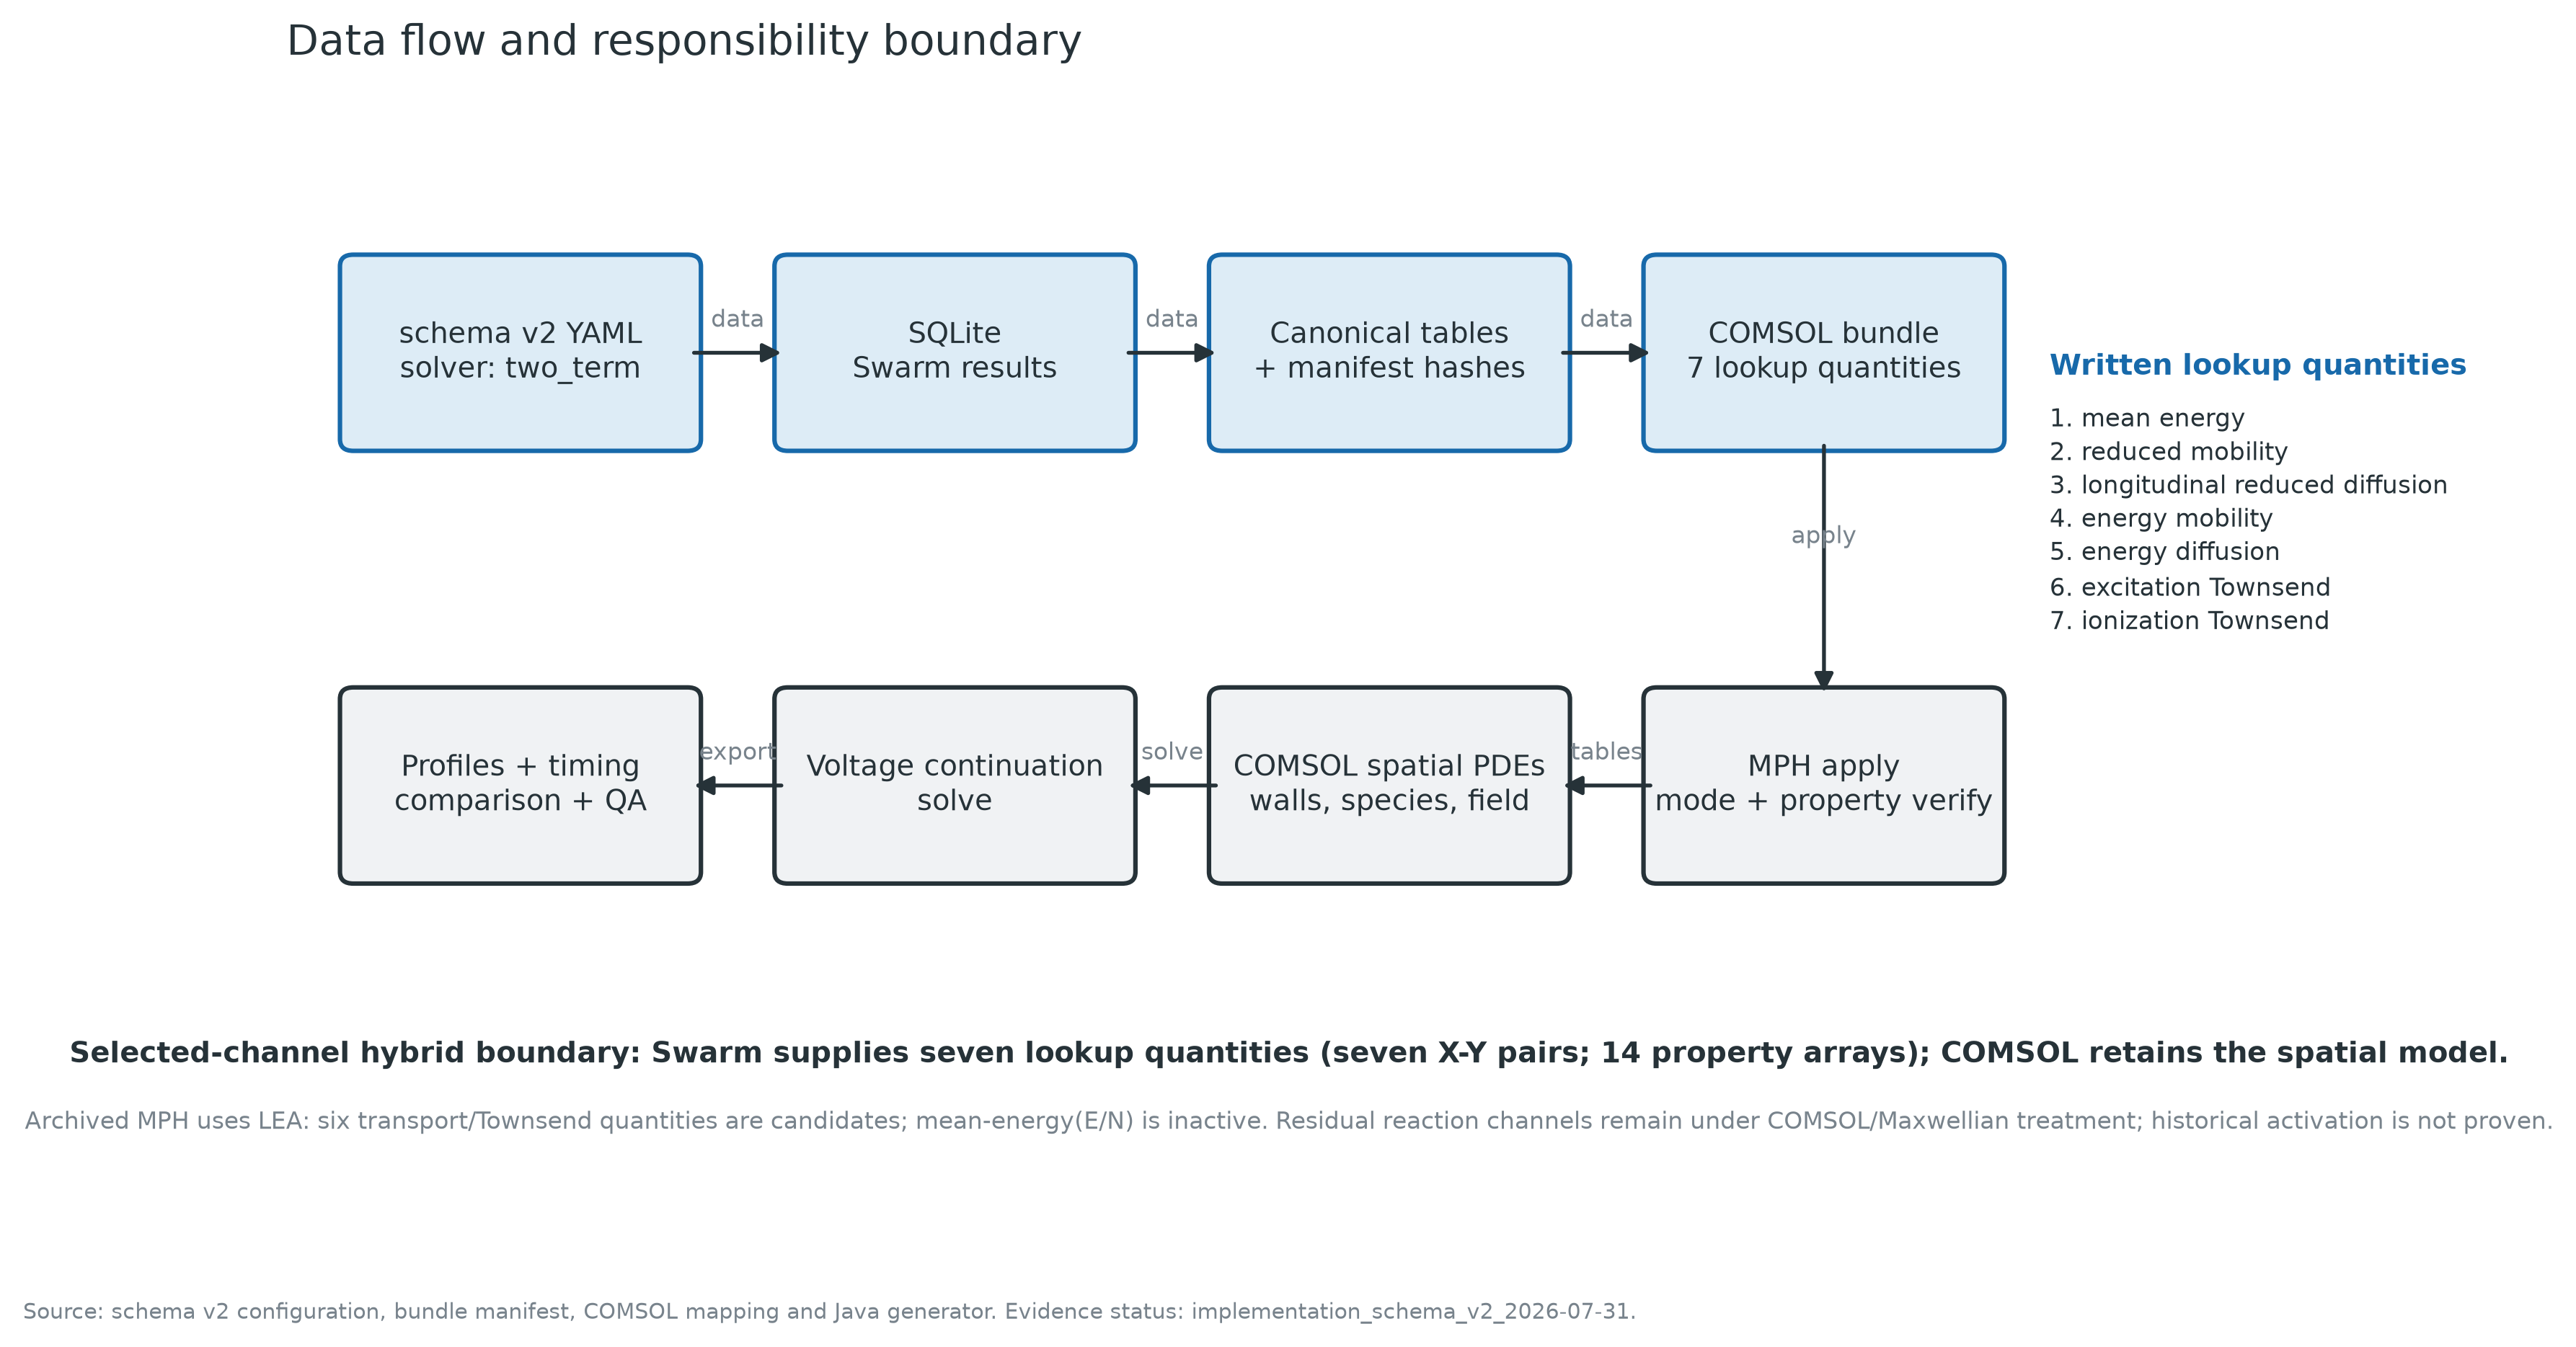

fig02_lookup_domain


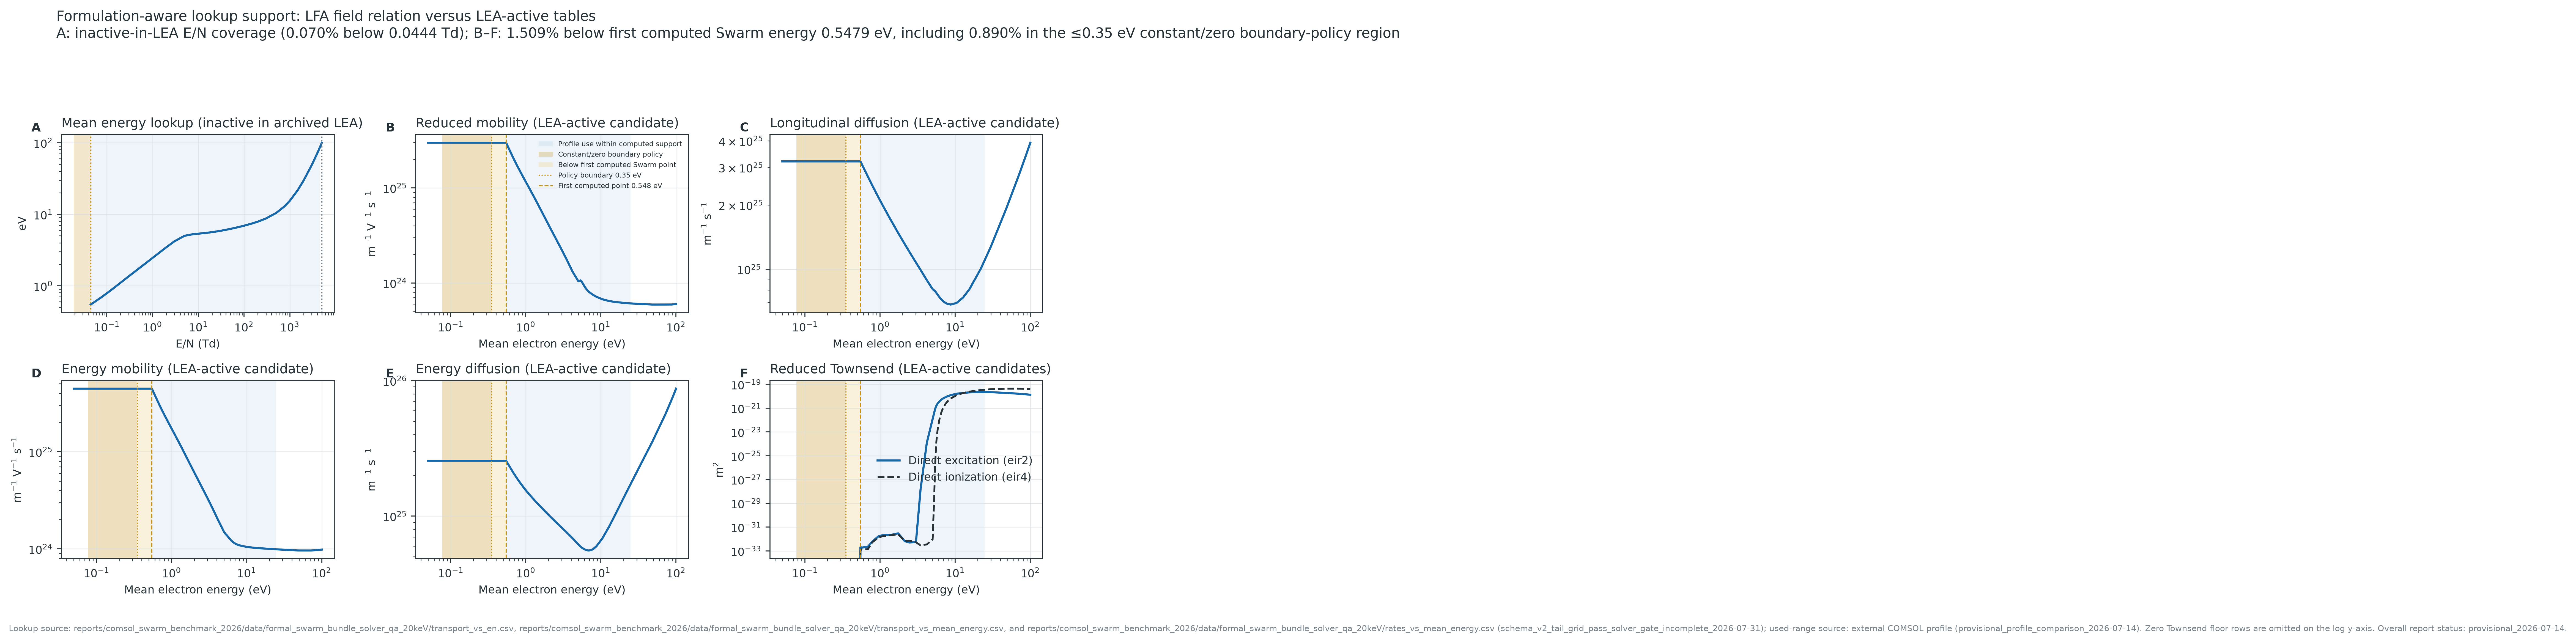

fig03_profile_state


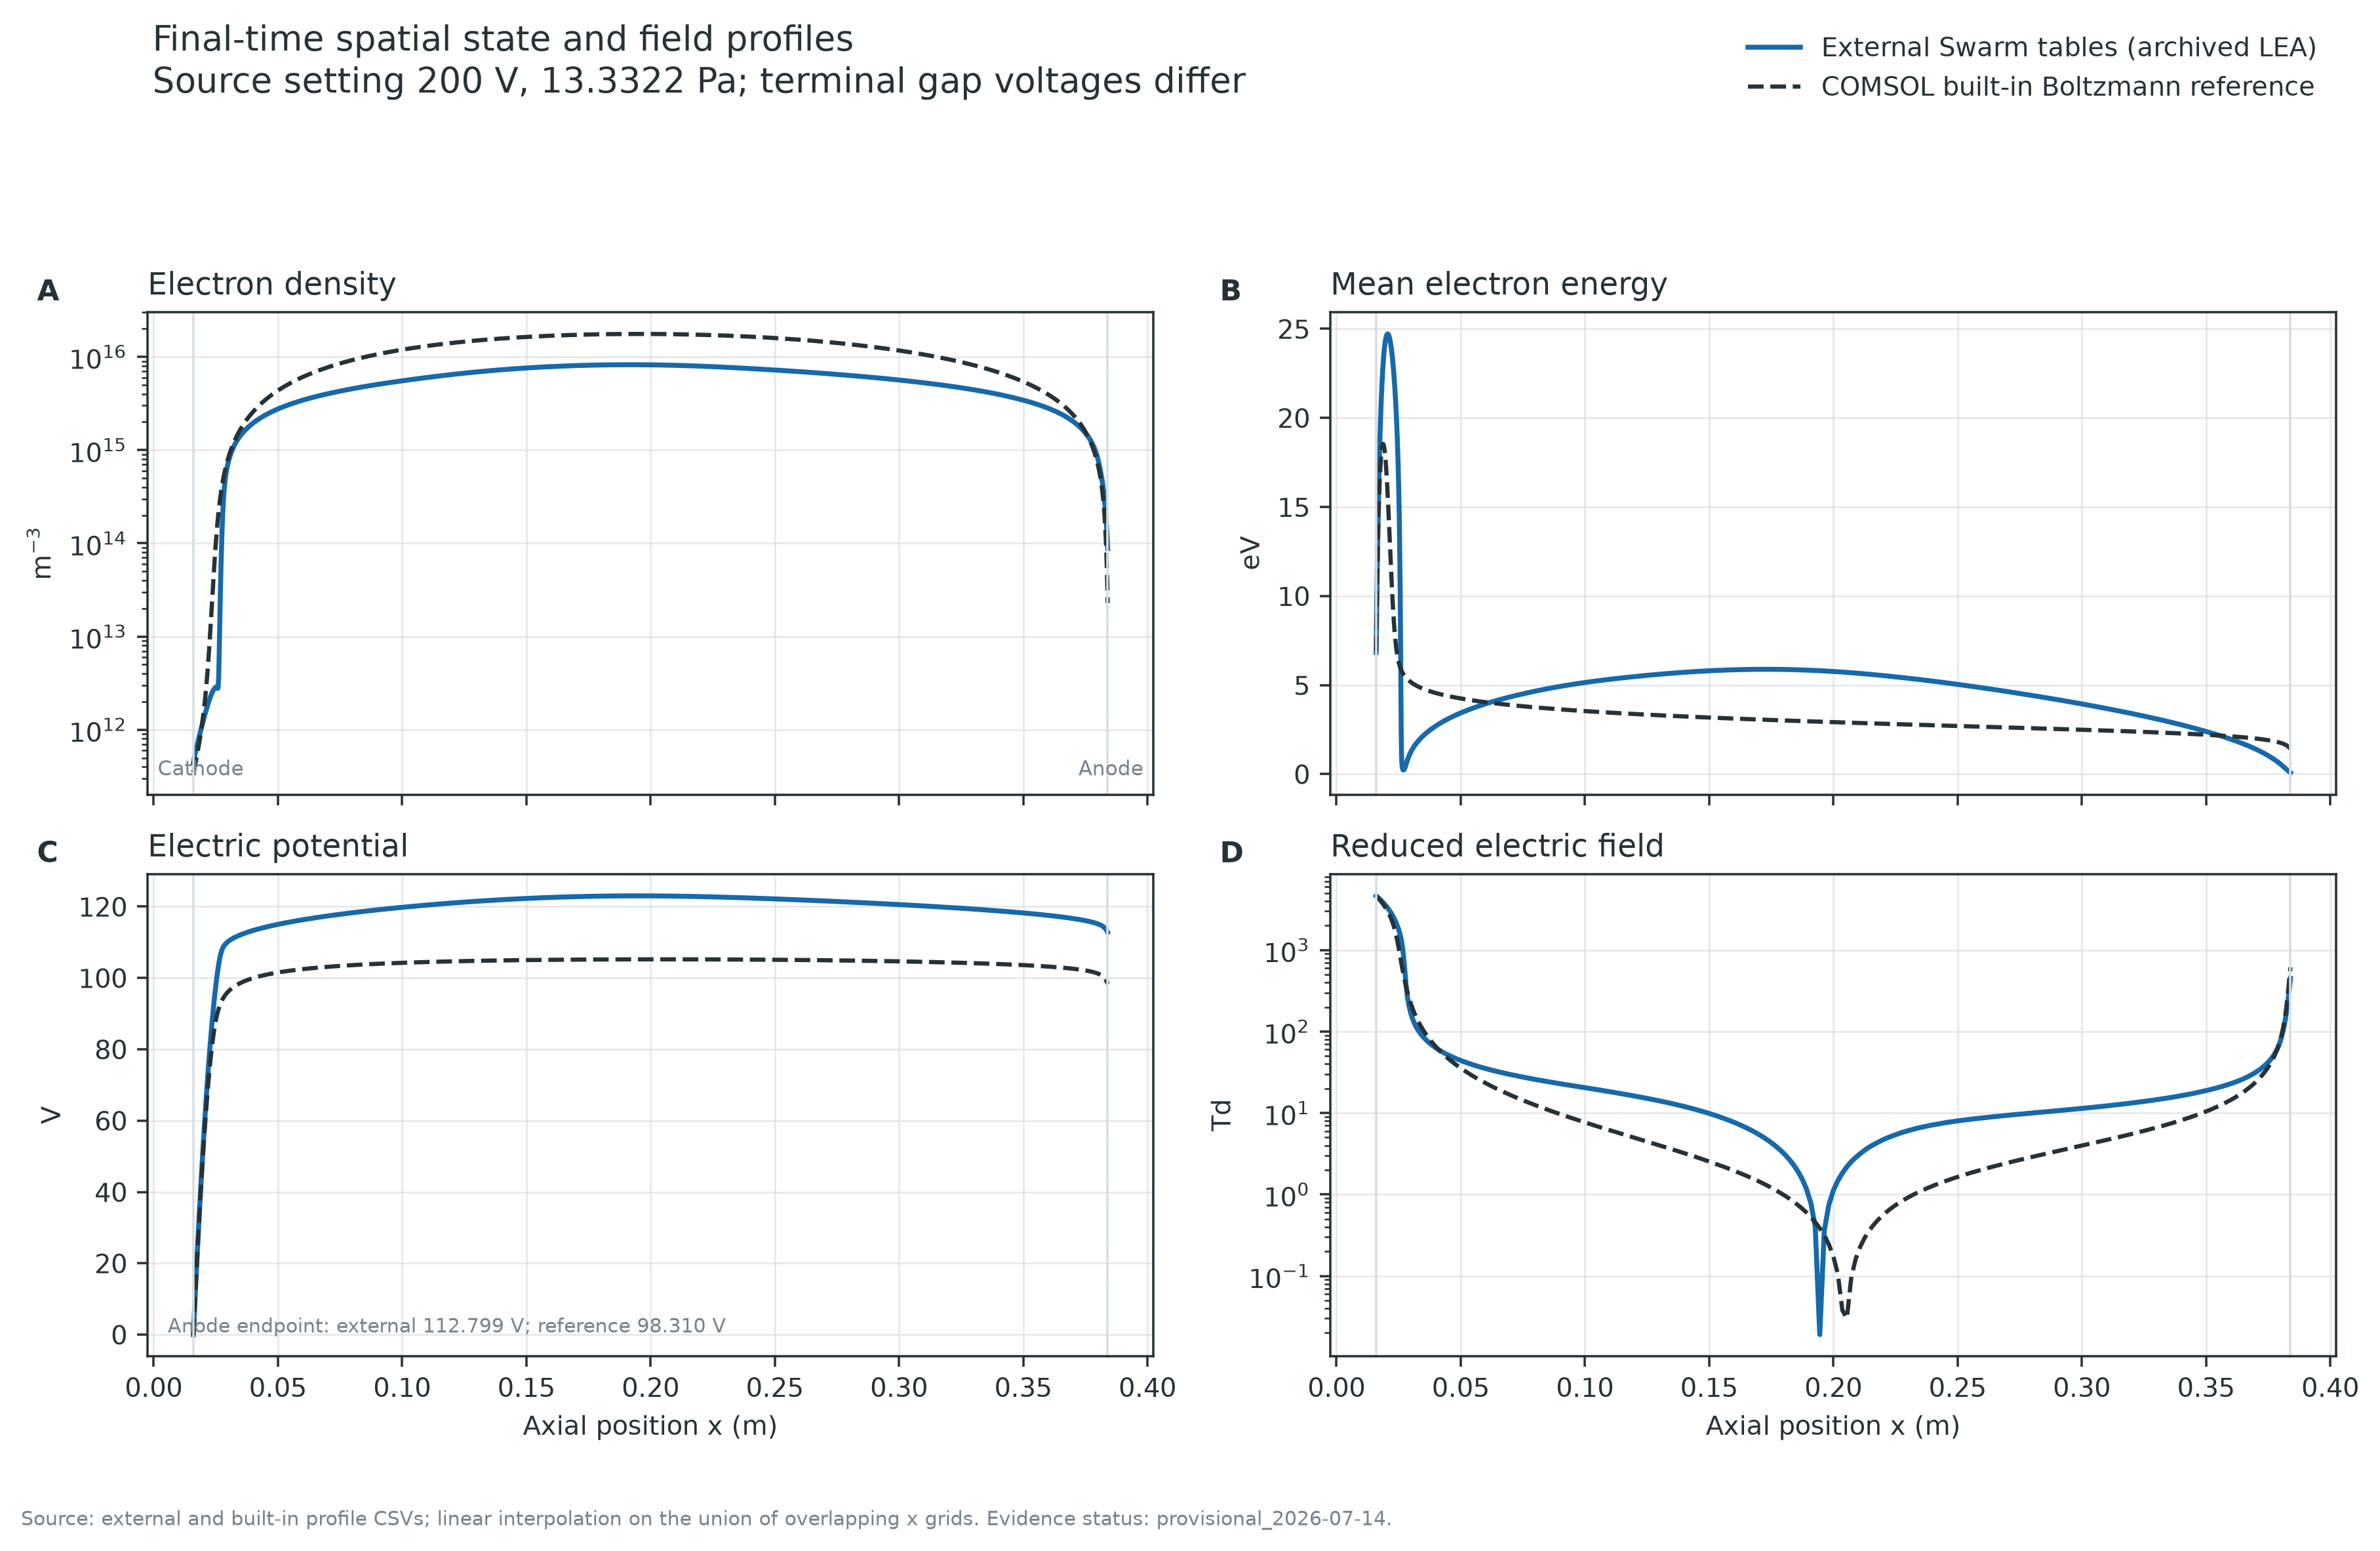

fig04_sources_currents_mesh


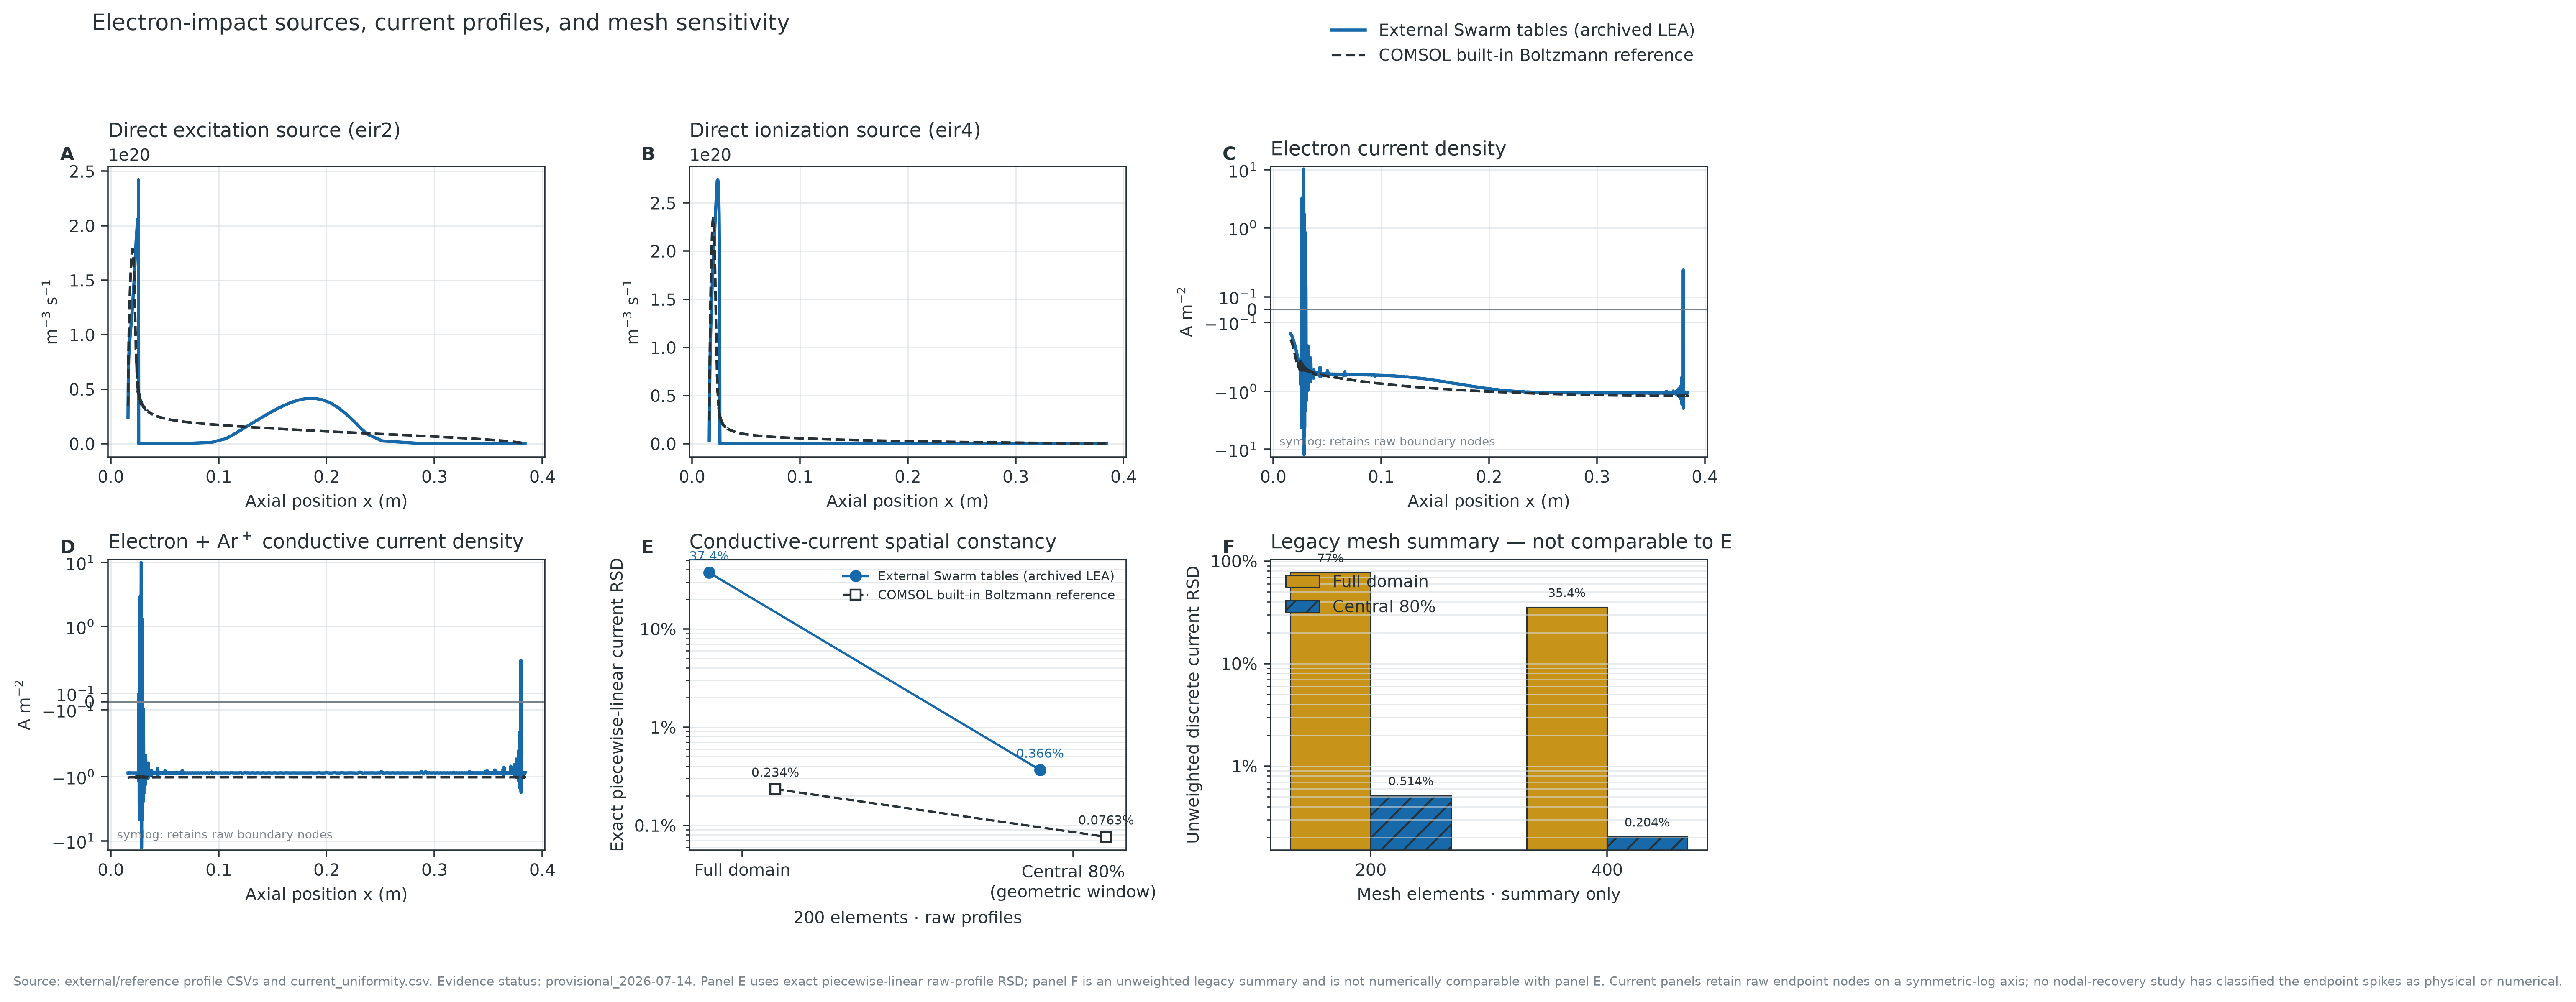

fig05_metric_summary


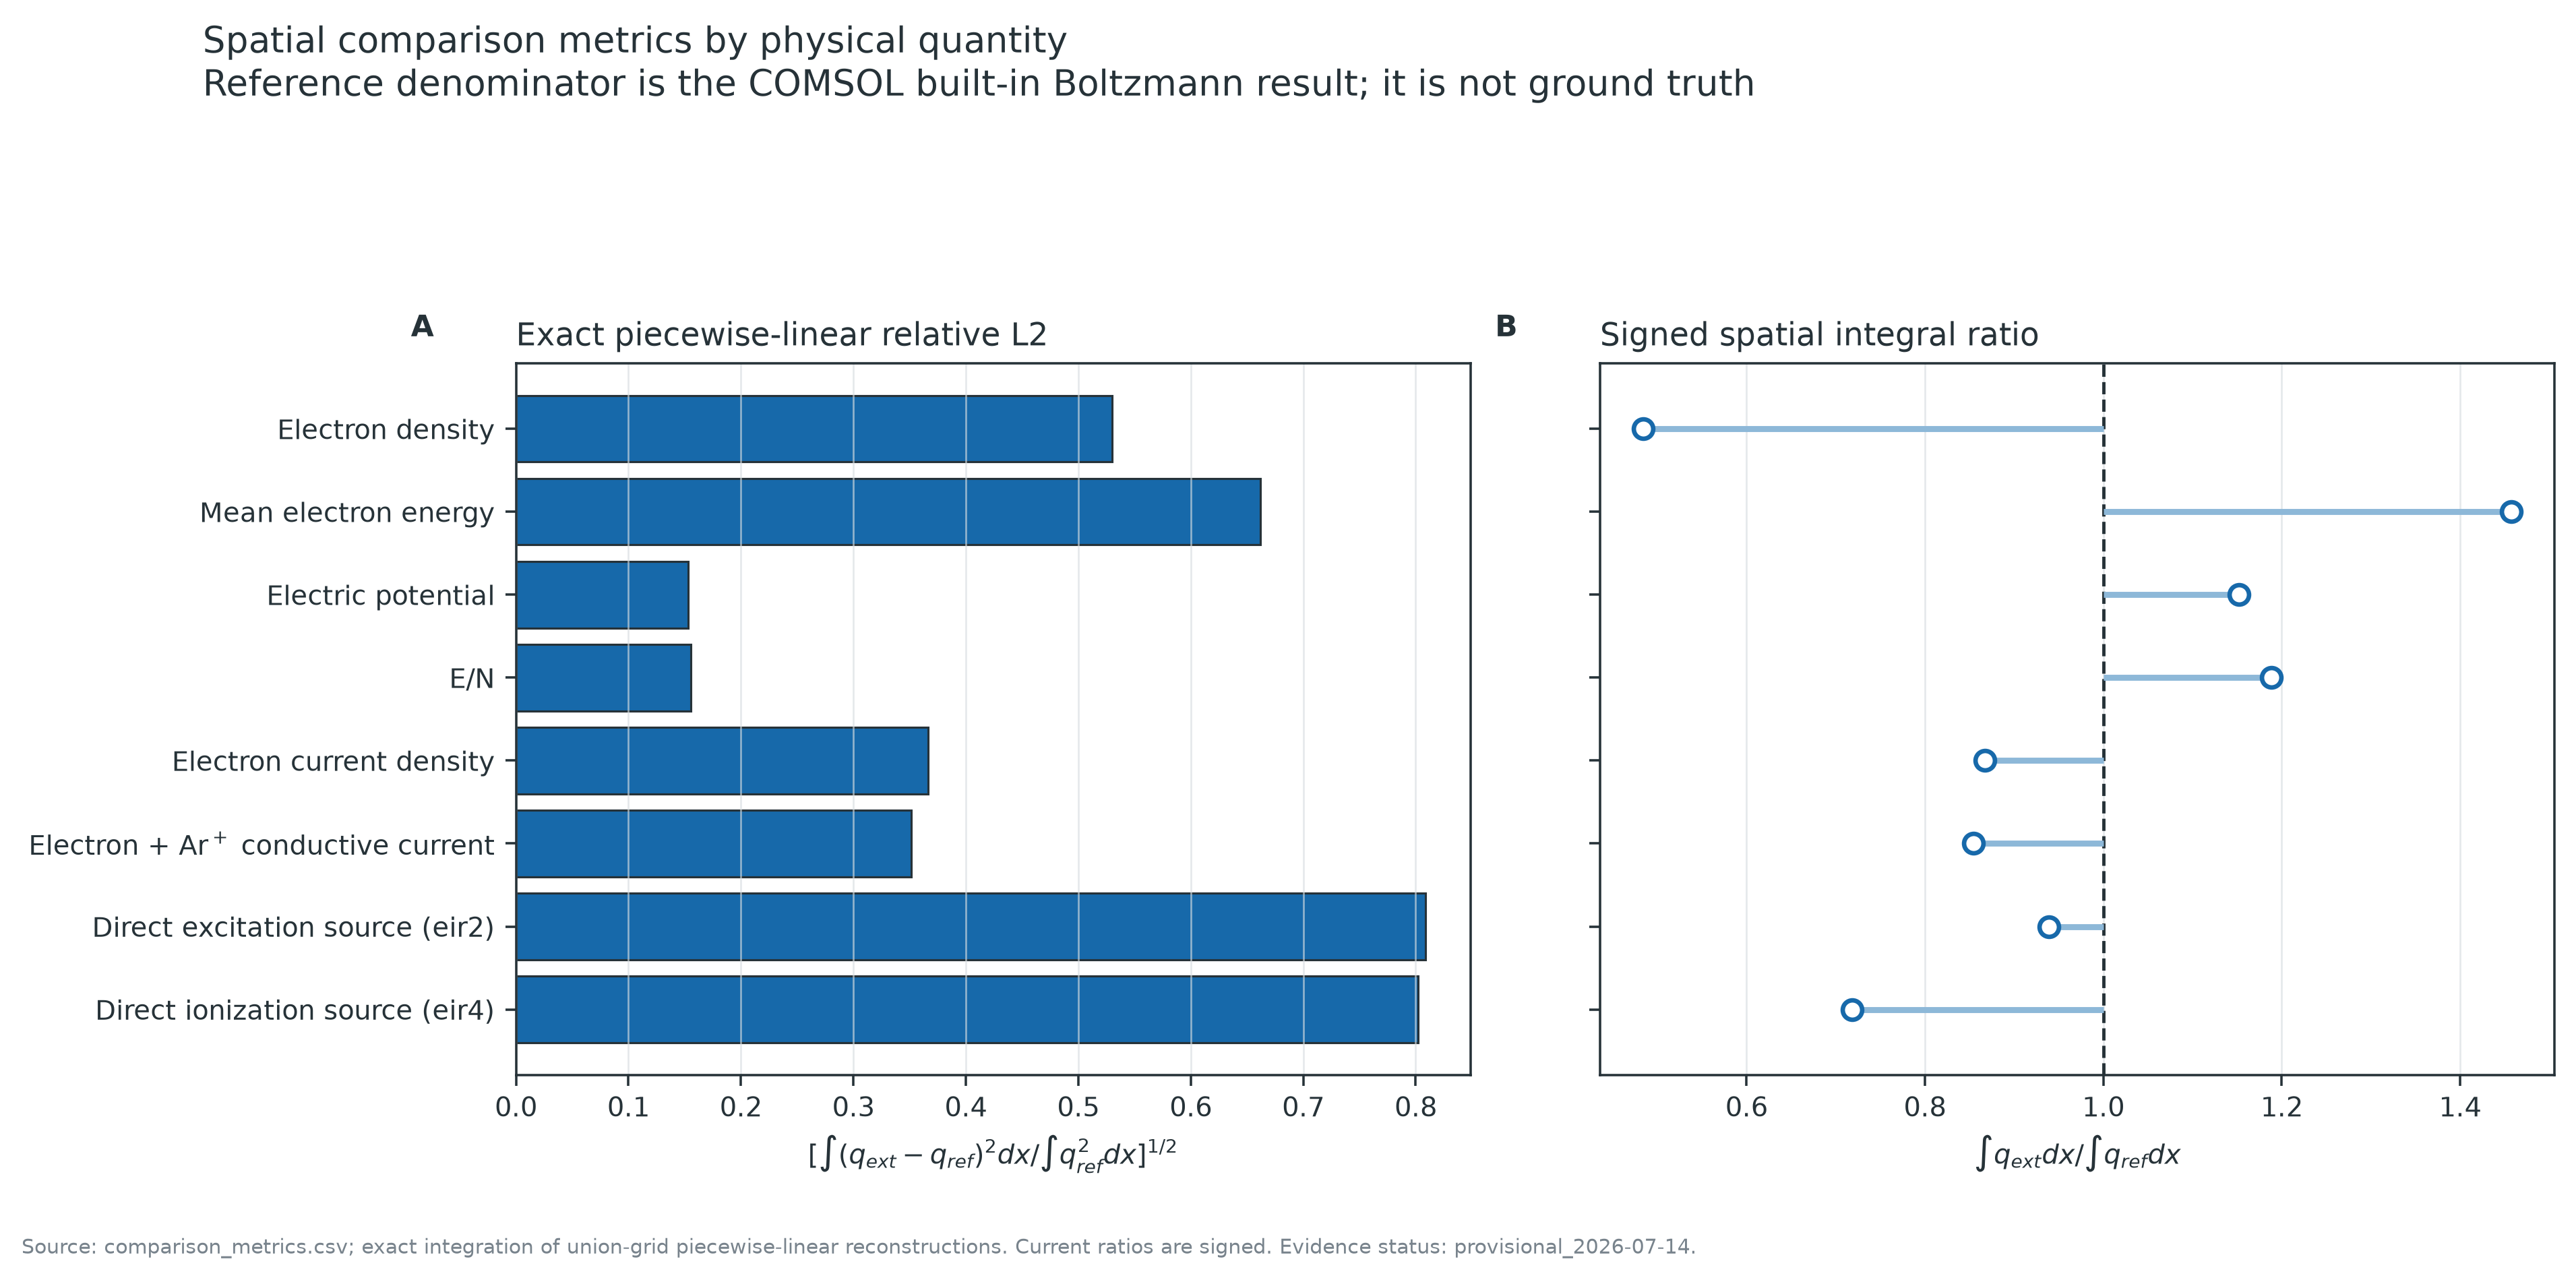

fig06_runtime_breakdown


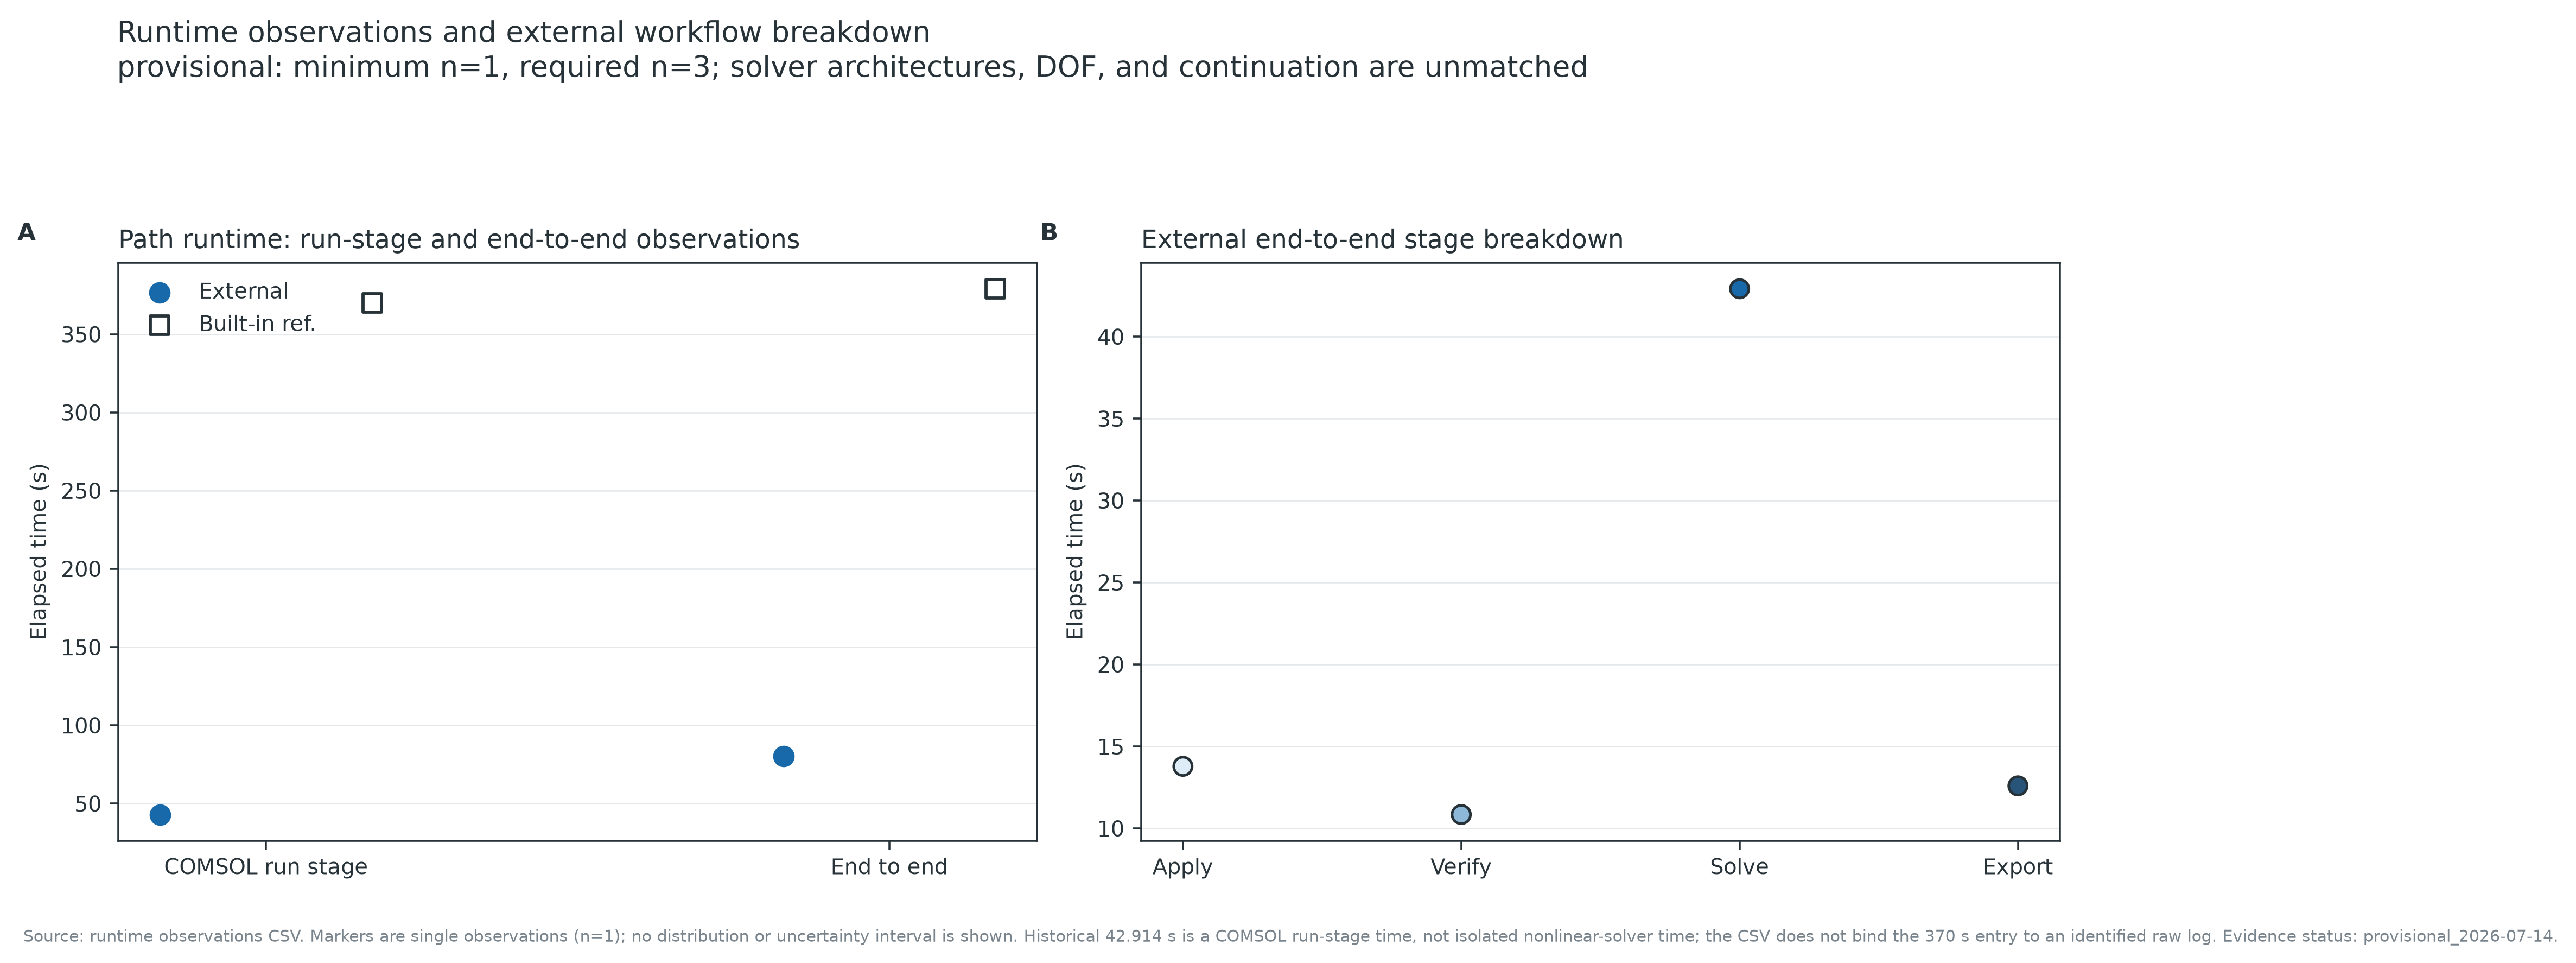

fig07_spatial_robustness


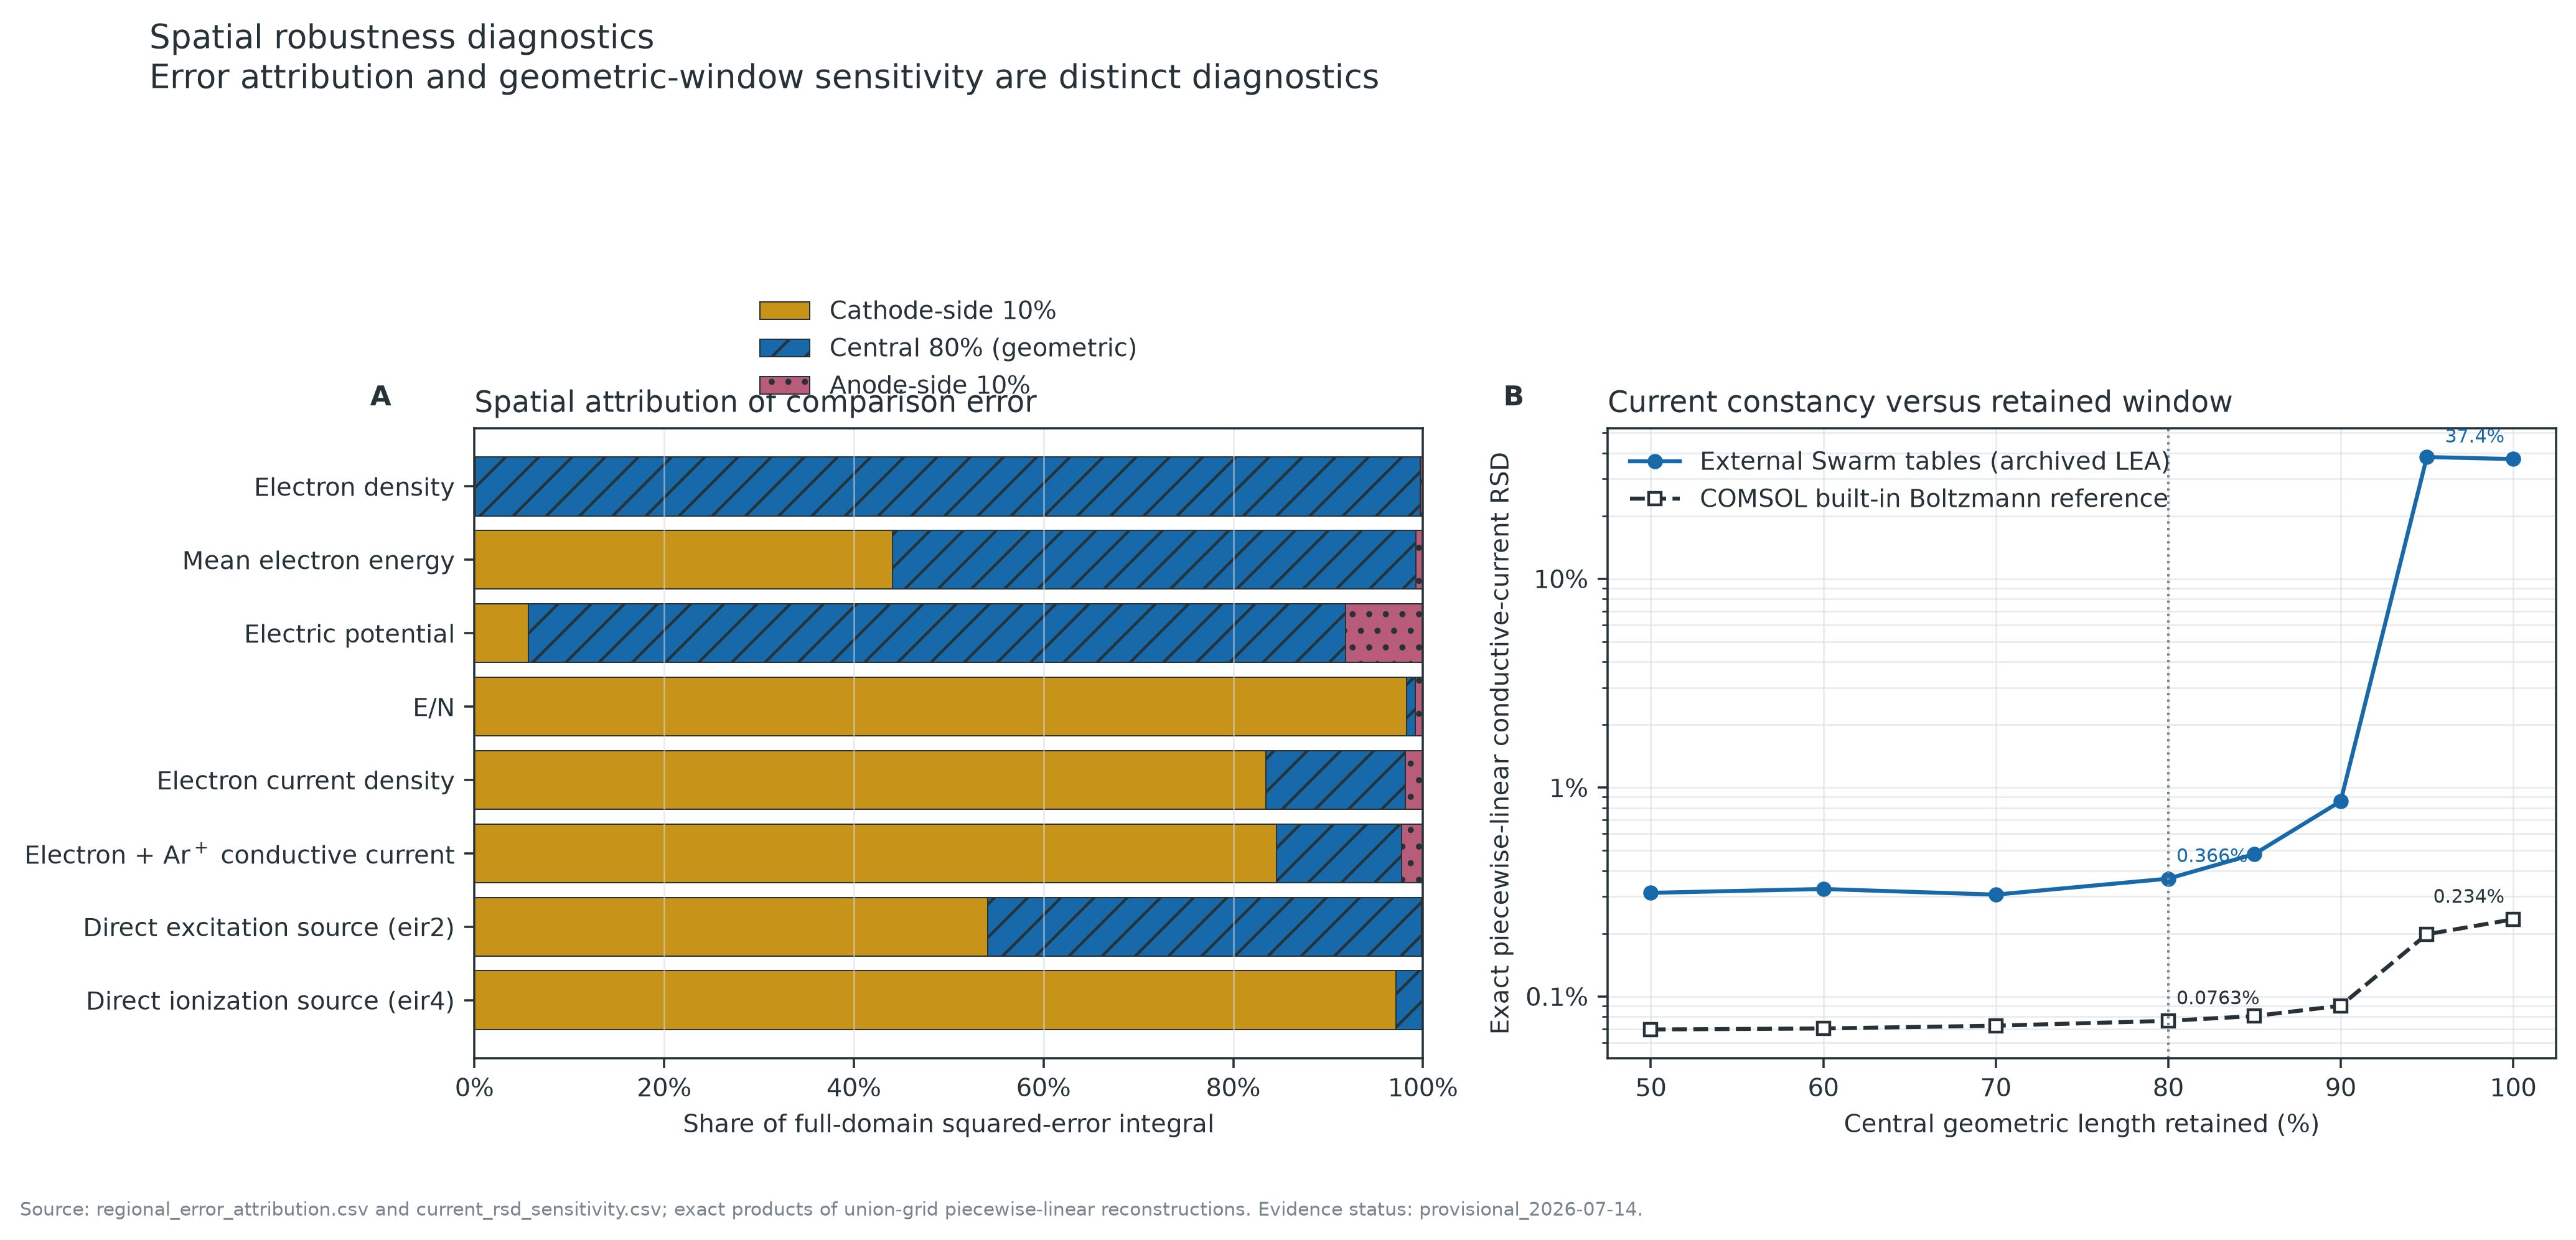

fig08_activation_regime


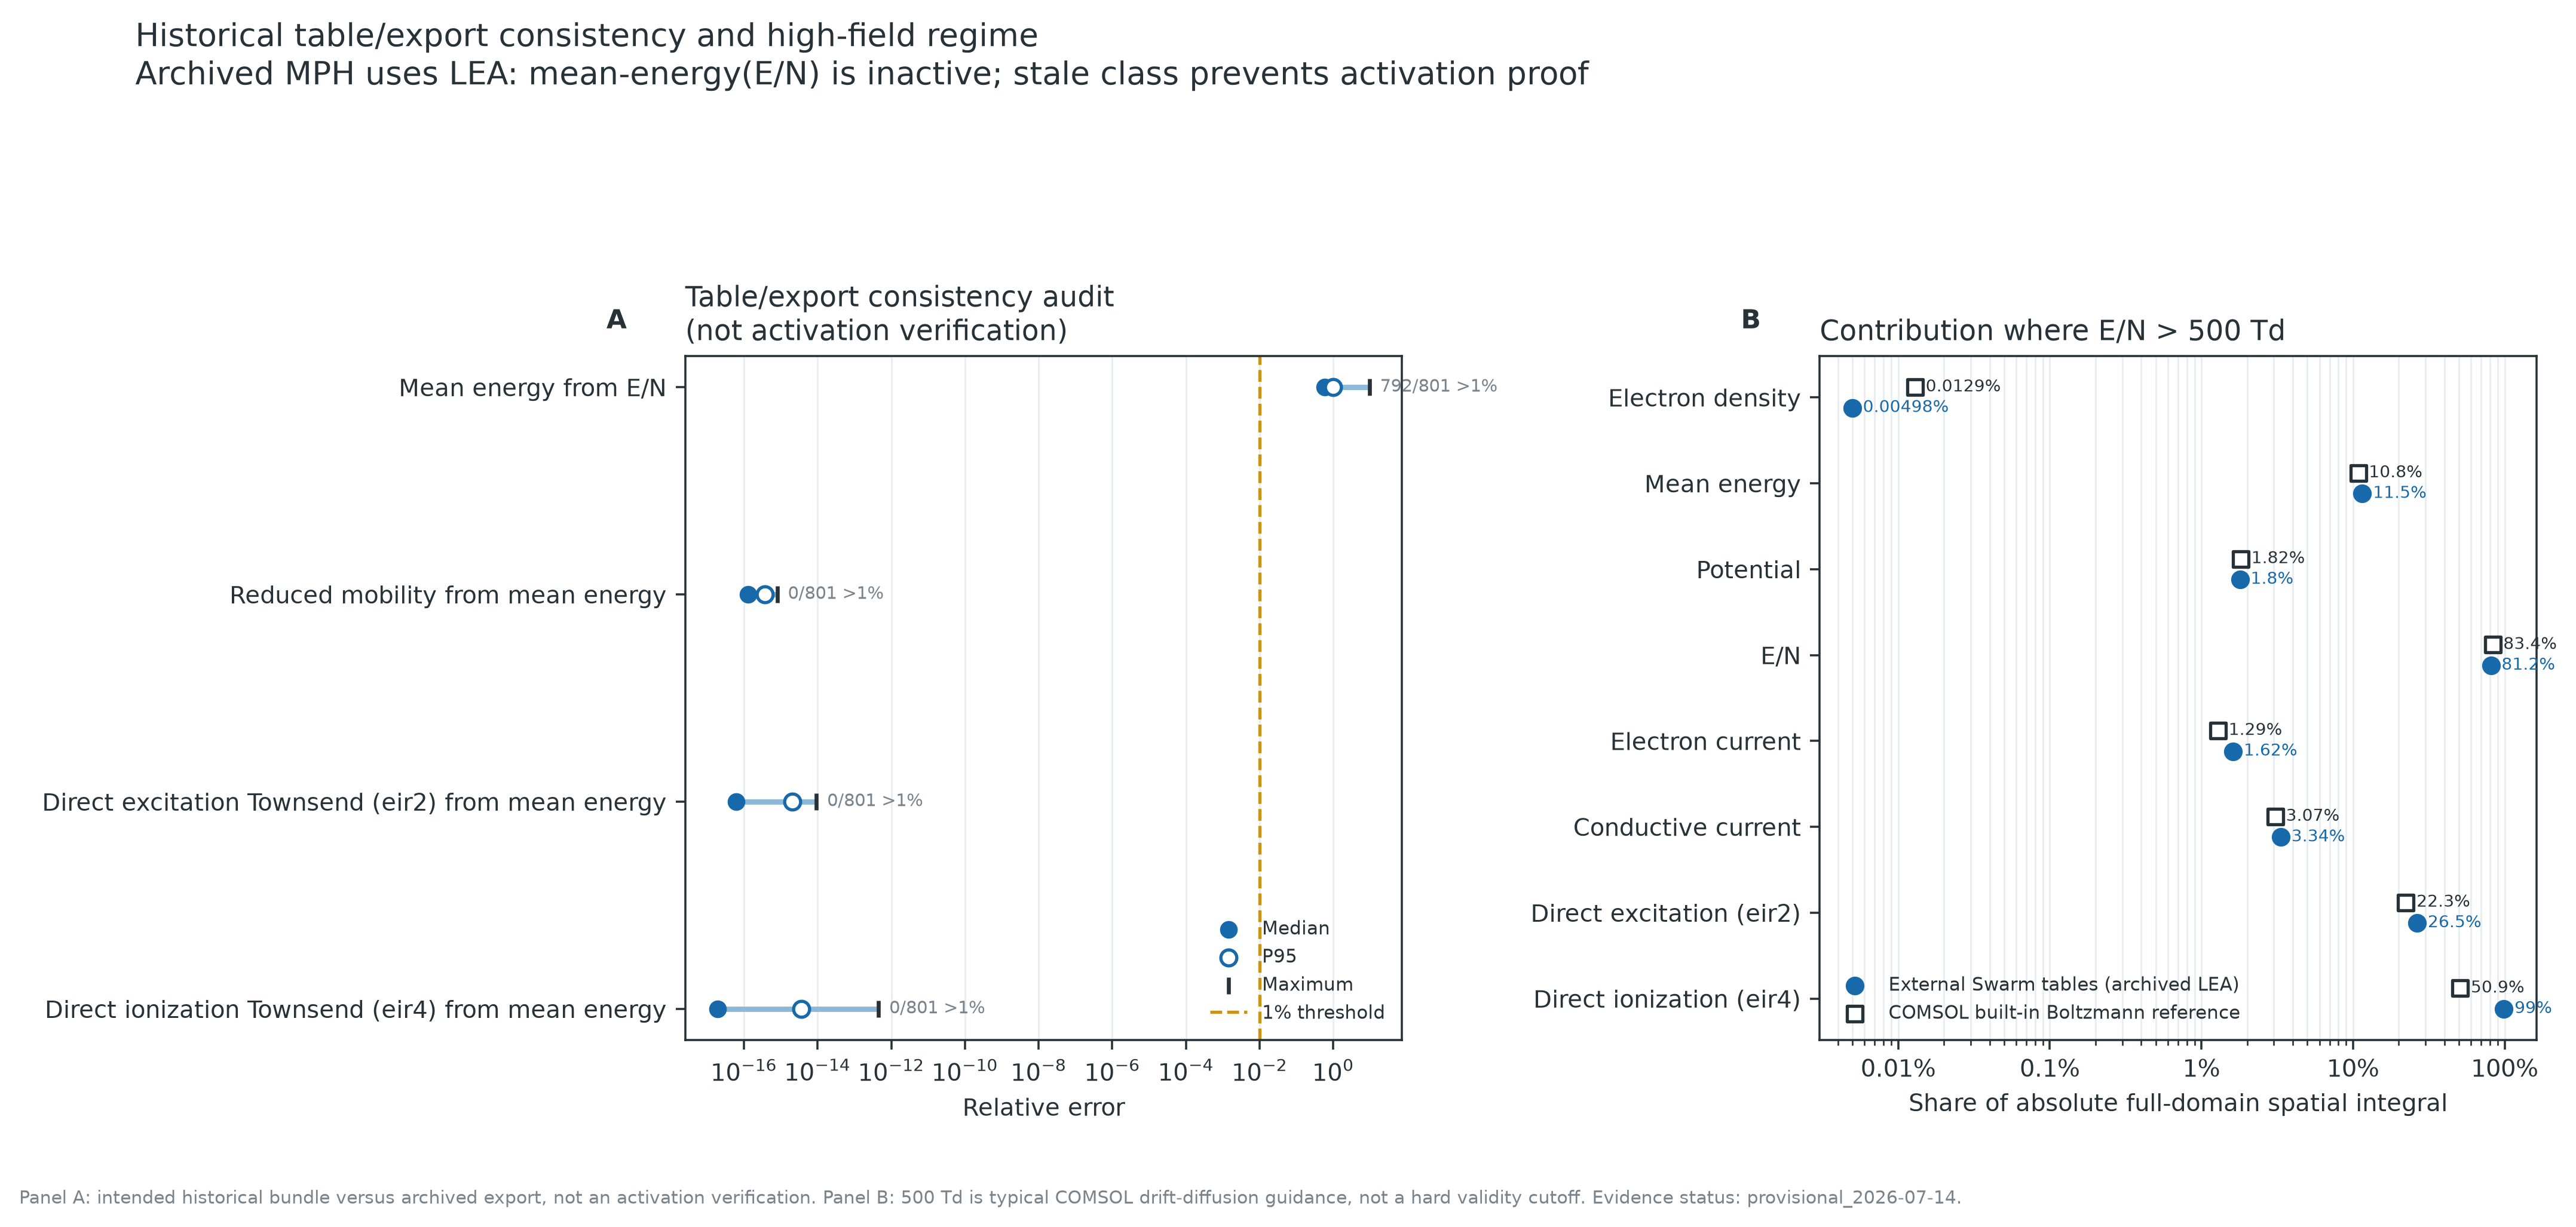

fig09_fluid_applicability


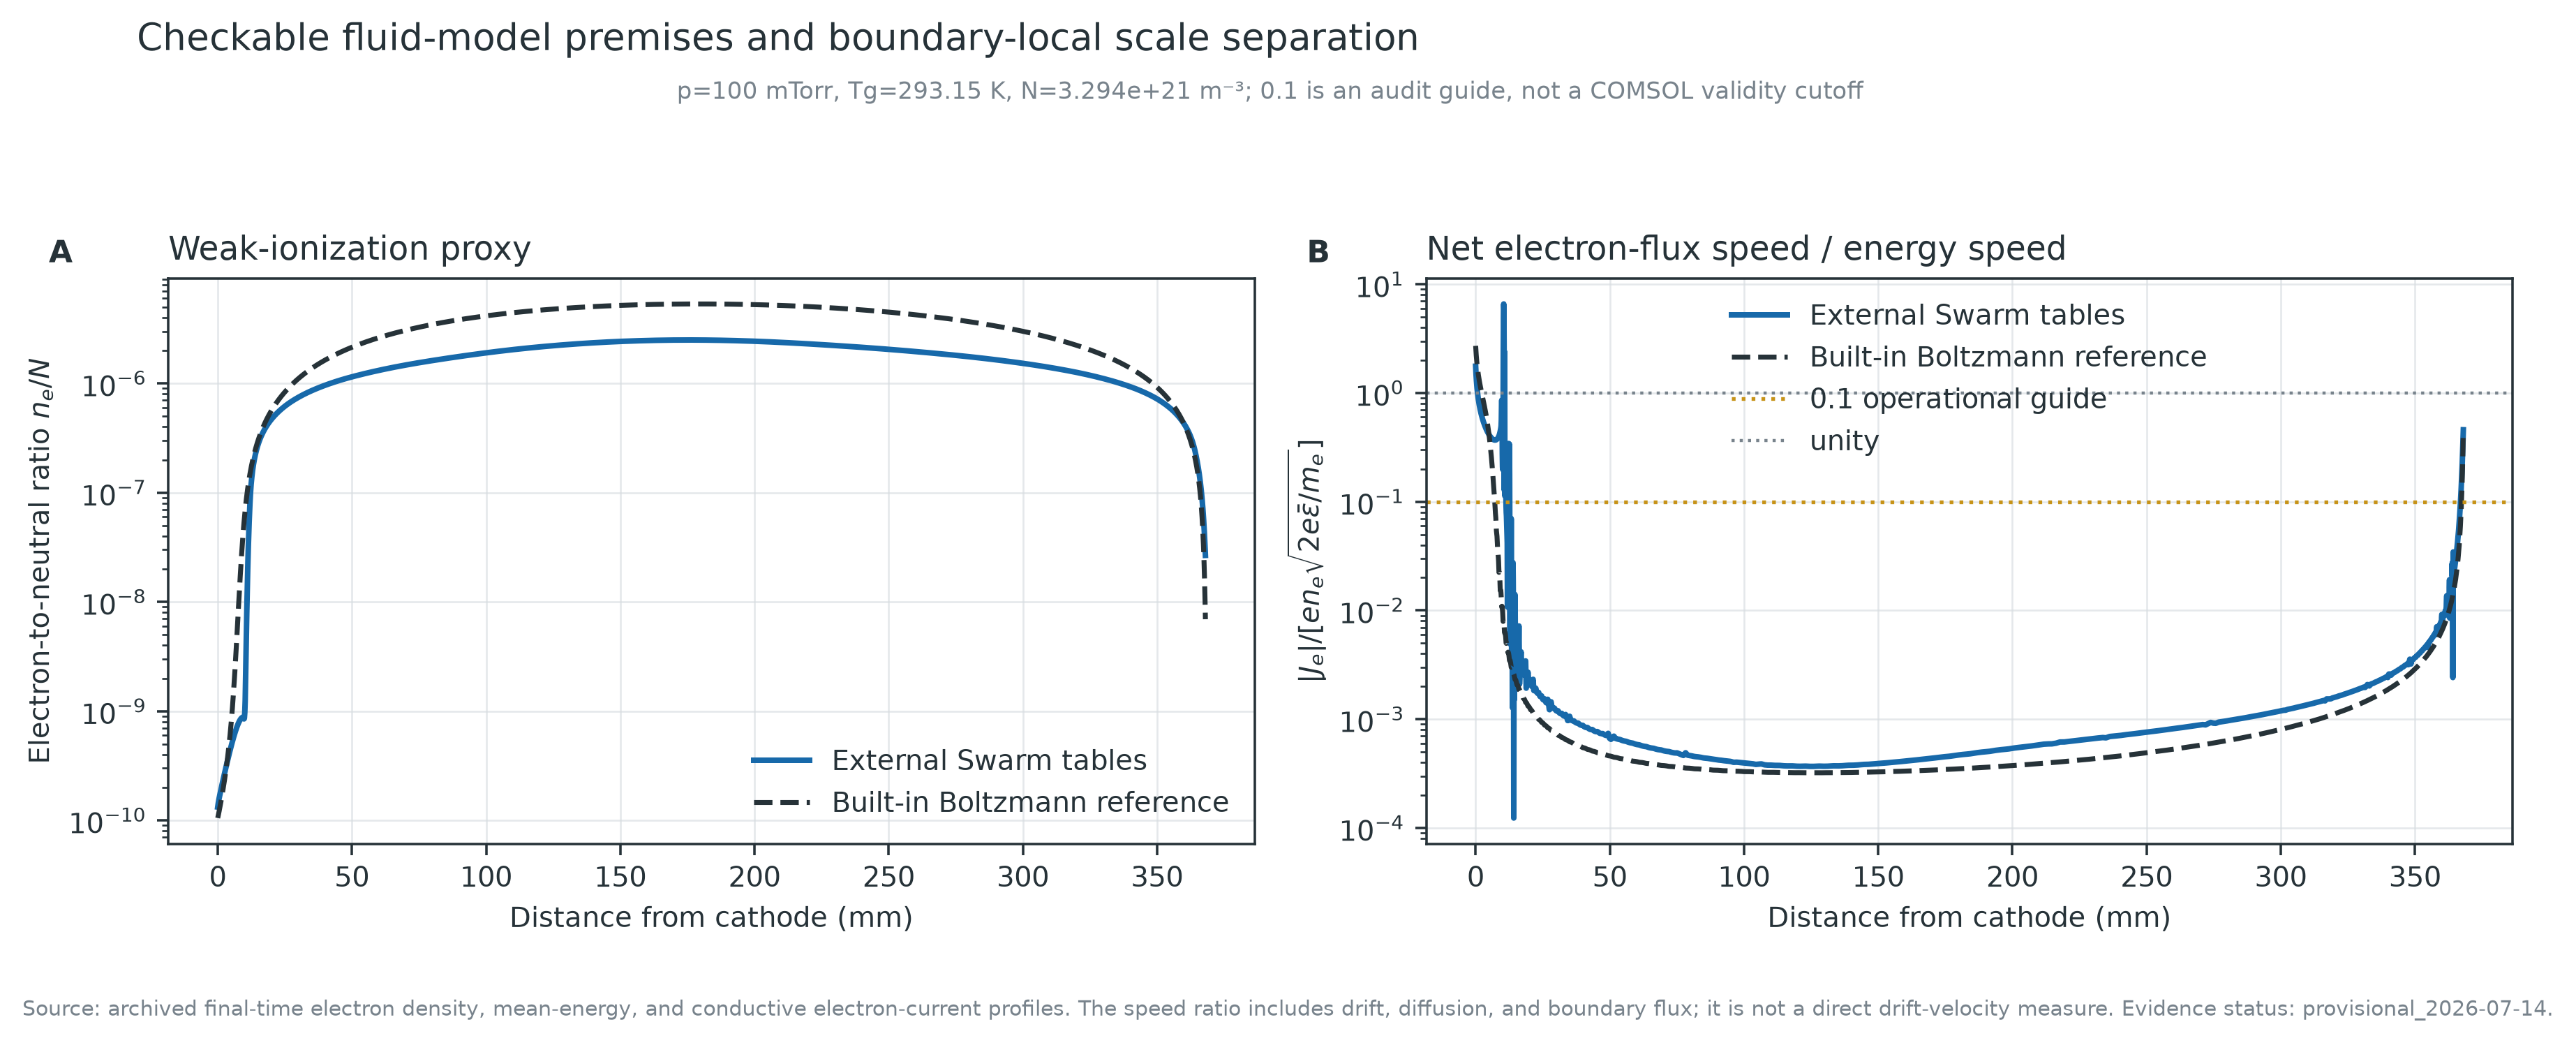

In [8]:
for figure_id in [
    'fig01_workflow_boundary', 'fig02_lookup_domain',
    'fig03_profile_state', 'fig04_sources_currents_mesh',
    'fig05_metric_summary', 'fig06_runtime_breakdown',
    'fig07_spatial_robustness', 'fig08_activation_regime',
    'fig09_fluid_applicability']:
    print(figure_id)
    display(Image(filename=str(REPORT_ROOT / 'figures' / f'{figure_id}.png'), width=850))

## Takeaways

- The present dataset remains **provisional_2026-07-14**; failed formal gates are visible above and must not be hidden in publication claims.
- Tail/grid adequacy is **34/34**, but solver convergence is only **23/34**; the lookup bundle is tail-audited, not a fully converged formal input.
- Shape correlation, weighted relative L2, and integral ratio are not interchangeable; conclusions must identify which metric supports them.
- In LEA, active lookup coverage must be assessed on the mean-energy axis; the explicit low-energy floor is a boundary policy, not a direct Swarm result.
- The >500 Td analysis separates lookup coverage from the physical regime risk of drift-diffusion/local closures.
- The source-form and partial-energy audits identify sensitivity and missing balance terms; neither is a matched rerun or a complete balance.
- The activation audit is historical: unresolved Java/class provenance prevents it from becoming a formal functional-activation result.
- Replace paths and evidence status in `repro/analysis_inputs.json` after clean runs; no analysis code change is required.